## COMP5625M Assessment 1 - Image Classification [100 marks]

<div class="logos"><img src="https://drive.google.com/uc?id=132BXgkV5w1bpXlVpdr5BtZdpagqYvna7" width="220px" align="right"></div>

The maximum number of marks for each part are shown in the section headers. As indicated in the main heading above, the overall assessment carries a maximum of 100 marks.

This summative assessment is weighted 25% of the final grade for the module.

### Motivation

Through this assessment, you will gain practical experience in:

> 1. Implementing and evaluating a multi-layer perceptron (MLP) and convolutional neural network (CNN) in solving a classification problem
> 2. Building, evaluating, and finetuning a CNN on an image dataset from development to testing
> 3. Tackling overfitting using strategies such as data augmentation and drop out
> 4. Fine tuning a model
> 5. Comparing the performance of a new model with an off-the-shelf model (AlexNet)
> 6. Gaining a deeper understanding of model performance using visualisations from Grad-CAM.


### Setup and resources

You must work using this template notebook.

Having a GPU will speed up the training process. See the provided document on Minerva about setting up a working environment for various ways to access a GPU. We highly recommend you use platforms such as Colab.

Please implement the coursework using **Python and PyTorch**, and refer to the notebooks and exercises provided.

This coursework will use a subset of images from Tiny ImageNet, which is a subset of the [ImageNet dataset](https://www.image-net.org/update-mar-11-2021.php). Our subset of Tiny ImageNet contains **30 different categories**, we will refer to it as TinyImageNet30. The training set has 450 resized images (64x64 pixels) for each category (13,500 images in total). You can download the training and test set from a direct link or the Kaggle challenge website:

>[Direct access to data is possible by clicking here, please use your university email to access this](https://leeds365-my.sharepoint.com/:u:/g/personal/scssali_leeds_ac_uk/ESF87mN6kelIkjdISkaRow8BublW27jB-P8eWV6Rr4rxtw?e=SPASDB)

>[Access data through Kaggle webpage](https://www.kaggle.com/t/917fe52f6a3c4855880a24b34f26db07)


### Required submissions

##### 1. Kaggle Competition
To participate in the submission of test results, you will need an account. Even if you have an existing Kaggle account, please carefully adhere to these instructions, or we may not be able to locate your entries:

> 1. Use your **university email** to register a new account.
> 2. Set your **Kaggle account NAME** to your university username, for example, ``sc15jb``.

The class Kaggle competition also includes a blind test set, which will be used in Question 1 for evaluating your custom model's performance on a test set. The competition website will compute the test set accuracy, as well as position your model on the class leaderboard. [Link to submit your results on Kaggle competition](https://www.kaggle.com/competitions/comp5623m-artificial-intelligence/submissions).

Please submit only your predictions from test set - detailed instructions are provided in (3)

##### 2. Submission of your work

Please submit the following:

> 1. Your completed Jupyter notebook file, without removing anything in the template, in **.ipynb format.**
> 2. The **.html version** of your notebook; File > Download as > HTML (.html). Check that all cells have been run and all outputs (including all graphs you would like to be marked) displayed in the .html for marking.
> 3. Your selected image from section 2.4.2 "Failure analysis".

**Final note:**

> **Please display everything that you would like to be marked. Under each section, put the relevant code containing your solution. You may re-use functions you defined previously, but any new code must be in the relevant section.** Feel free to add as many code cells as you need under each section.



Your student username (for example, ```sc15jb```):

mm22afbf

Your full name:

Achmad Fauzi Bagus Firmansyah

## Required packages

[1] [numpy](http://www.numpy.org) is a package for scientific computing with python

[2] [h5py](http://www.h5py.org) is a package to interact with compactly stored dataset

[3] [matplotlib](http://matplotlib.org) can be used for plotting graphs in python

[4] [pytorch](https://pytorch.org/docs/stable/index.html) is a library widely used for bulding deep-learning frameworks

Feel free to add to this section as needed - examples of importing libraries are provided below.

You may need to install these packages using [pip](https://pypi.org/project/opencv-python/) or [conda](https://anaconda.org/conda-forge/opencv).

In [ ]:
import math
import numpy as np
import h5py as h5
import torch
from torch import nn, optim
import torchvision
from torchvision import transforms, datasets
from torch.hub import load_state_dict_from_url
from PIL import Image
import matplotlib.pyplot as plt
import os
from glob import glob
import pandas as pd
!pip install natsort
from natsort import natsorted
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
torch.manual_seed(0)


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# always check your version
print(torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device used: ',device)

1.13.1+cu116
Device used:  cuda


One challenge of building a deep learning model is to choose an architecture that can learn the features in the dataset without being unnecessarily complex. The first part of the coursework involves building a CNN and training it on TinyImageNet30.

### **Overview:**

**1. Function implementation** (12 marks)

*   **1.1** PyTorch ```Dataset``` and ```DataLoader``` classes (4 marks)
*   **1.2** PyTorch ```Model``` class for a simple MLP model (4 marks)
*   **1.3** PyTorch ```Model``` class for a simple CNN model (4 marks)

**2. Model training** (20 marks)
*   **2.1** Train on TinyImageNet30 dataset (7 marks)
*   **2.2** Generate confusion matrices and ROC curves (4 marks)
*   **2.3** Strategies for tackling overfitting (9 marks)
    *   **2.3.1** Data augmentation
    *   **2.3.2** Dropout
    *   **2.3.3** Hyperparameter tuning (e.g. changing learning rate)
            

**3. Model Fine-tuning on CIFAR10 dataset** (20 marks)
*   **3.1** Fine-tune your model (initialise your model with pretrained weights from (2)) (8 marks)
*   **3.2** Fine-tune model with frozen base convolution layers (8 marks)
*   **3.3** Compare complete model retraining with pretrained weights and with frozen layers. Comment on what you observe? (4 marks)

**4. Model testing** (18 marks)
*   **4.1**   Test your final model in (2) on test set - code to do this (10 marks)
*   **4.2**   Upload your result to Kaggle  (8 marks)

**5. Model comparison** (14 marks)
*   **5.1**   Load pretrained AlexNet and finetune on TinyImageNet30 until model convergence (6 marks)
*   **5.2**   Compare the results of your CNN model with pretrained AlexNet on the same validation set. Provide performance values (loss graph, confusion matrix, top-1 accuracy, execution time) (8 marks)

**6. Interpretation of results** (16 marks)
*   **6.1** Use grad-CAM on your model and on AlexNet (6 marks)
*   **6.2** Visualise and compare the results from your model and from AlexNet (4 marks)
*   **6.3** Comment on (6 marks):
    - why the network predictions were correct or not correct in your predictions?
    - what can you do to improve your results further?

## 1 Function implementations [12 marks]


### 1.1 Dataset class [4 marks]

#### a. Data Preparation and Description

Here, the data is downloaded manually from the link and then unzipped into appropriate working directory in google drive.

In [ ]:
## Mounting the google drive
from google.colab import drive
drive.mount('/content/drive')
ROOT='/content/drive/MyDrive/Master in Leeds/Deep Learning/Assignment 1/'


Mounted at /content/drive


In [ ]:
## Unzip the data
## The following code is commented since it's already unzipped.
# !unzip -o -qq '/content/drive/MyDrive/Master in Leeds/Deep Learning/Assignment 1/comp5625M_data_assessment_1.zip' -d '/content/drive/MyDrive/Master in Leeds/Deep Learning/Assignment 1/'



Here, we get dataset from `train_set/train_set/` .

The code below show the brief number class and name of class in data from the folder

In [ ]:
# Define the path for train and test
# If processing in Kaggle
#ROOT='/kaggle/input/comp5623m-artificial-intelligence/'

train_path=ROOT+'train_set/train_set/'
# get the classes name
classes=glob(train_path+'*')
classes=[i.split('/')[-1] for i in classes if i.split('/')!='']

# get the count for each classes
dict_class={}
for i in classes:
  images=glob(train_path+i+'/*.JPEG')
  dict_class[i]=len(images)

In [ ]:
print('Table 1. Number of images for each classes')
display(pd.DataFrame.from_dict(dict_class,
                               orient='index').reset_index().rename(
                                  columns={'index':'class',0:'count'}))

Table 1. Number of images for each classes


,class,count
0,butterfly,450
1,ladybug,450
2,pig,450
3,hourglass,450
4,mushroom,450
5,bee,450
6,fly,450
7,candle,450
8,goldfish,450
9,penguin,450


Here, we have 30 classes with balance data (each class has 450 images).

#### B. Creating the data loader for both train and test

This code is used for applying dataset and dataloader architecture.
Instead of using all images from the folder, we split the dataset into 80% and 20% which represent *training dataset* and *validation dataset*.

In addition to that, we specify two transformations:
1. to tensor: convert image into tensor
2. normalize: normalize the image, by applying mean and std from IMAGENET

We also made the customized class dataloader which purposed to load data from the folder.

For the loader we specify the parameter, as follow:
- batch size =64
- shuffle =True

In [ ]:
transform_1 = transforms.Compose([
    # base transformation
    transforms.ToTensor(),
    # Normalize with Imagenet mean and std
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

# Define LoadFromFolder
class LoadFromFolder(Dataset):
    def __init__(self, main_dir, transform=transform_1):
        self.main_dir = main_dir
        self.transform = transform
        all_imgs = os.listdir(main_dir)
        self.total_imgs = natsorted(all_imgs)
    def __len__(self):
        return len(self.total_imgs)
    def __getitem__(self, idx):
        img_loc = os.path.join(self.main_dir, self.total_imgs[idx])

        # Use PIL for image loading
        image = Image.open(img_loc).convert("RGB")
        # Apply the transformations
        tensor_image = self.transform(image)
        return tensor_image, self.total_imgs[idx]

In [ ]:

dataset = ImageFolder(root=train_path,transform=transform_1)

# create the dataset
train_ds, valid_ds = torch.utils.data.random_split(dataset, [0.8, 0.2])
# create the dataloader
train_dl = DataLoader(train_ds,batch_size=64,shuffle=True, num_workers=2)
valid_dl = DataLoader(valid_ds,batch_size=64,shuffle=True, num_workers=2)

In [ ]:
## Save the dataloader into pytorch file!
# ROOT_WORK='/kaggle/working/'
ROOT_WORK='/content/drive/MyDrive/Master in Leeds/Deep Learning/Assignment 1/'

#### c. Train and Validation Description

The code below are used for producing the table for showing the brief description about:
- number of images for both training and validation dataset
- number of images used for testing

In [ ]:
print('Number of images for training', train_ds.__len__())
print('Number of images for validation', valid_ds.__len__())

Number of images for training 10800
Number of images for validation 2700


#### c. Show sample of images in batch

The code here used for displaying the sample images.

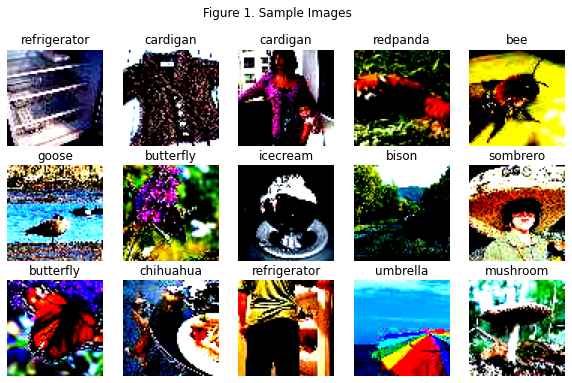

In [ ]:
figure= plt.figure(figsize=(10, 6))
cols, rows = 5, 3
labels_map=dataset.class_to_idx

#get one batch
train_features, train_labels = next(iter(train_dl))
for i in range(1, cols * rows + 1):
  img = train_features[i].squeeze()
  label = train_labels[i]
  figure.add_subplot(rows, cols, i)
  plt.title(list(labels_map.keys())[list(labels_map.values()).index(label.item())])
  img = np.transpose(img.numpy(),(1,2,0))
  plt.imshow(img.squeeze())
  plt.axis('off')

figure.suptitle('Figure 1. Sample Images')
plt.show()

Additionally, we also check the image shape.

In [ ]:
print('Images size:',train_features[0].shape )

Images size: torch.Size([3, 64, 64])


### 1.2 Define a MLP model class [4 marks]

The following code describe the architecture of designed MLP. Briefly, the network is consisting combination of linear network with ReLU activation functions.

In [ ]:
## MLP model
## This code is MLP network configureation
class NetMLP(nn.Module):
    def __init__(self, num_classes=30):
        super(NetMLP, self).__init__()
        self.flatten=nn.Flatten()
        self.fc1 = nn.Linear(3 * 64 * 64, 4096)
        self.relu=nn.ReLU()
        self.fc2=nn.Linear(4096,4096)
        self.fc3=nn.Linear(4096,1024)
        self.fc4=nn.Linear(1024,num_classes)
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x
## Number of parameter
net_=NetMLP()
y_=sum(p.numel() for p in net_.parameters())
print(f'Number of Paramaters in this MLP network: {y_}')

Number of Paramaters in this MLP network: 71343134


### 1.3 Define a CNN model class [4 marks]

The following code describe the architecture of base CNN models designed. The CNN models is consisting of:
1. Several Block of Convolutionals
2. Fully Connected Layers

Additionally, we also calculate the height and width of images after passing layer in convolutional block, by using this formula.

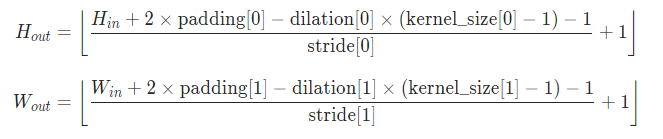

Detail image Size calculation:

(Since the height and width is symetrical, the calculation only written for height, denoted as H)

Input image: 64x64

1. Conv2D_1: kernel_size=3  and padding =1; H: ((64 +2 x 1 - 1 x(3-1)-1)/1)+1 = 64
2. Conv2D_2: kernel_size=3  and padding =1; H: ((64 +2 x 1 - 1 x(3-1)-1)/1)+1 = 64;
  
  Followed with MaxPool2D: kernel_size=2 and stride=2; H: (( 64 + 2 x0 -1x(2-1)-1)/2)+1 = 32
3. Conv2D_3: kernel_size=3  and padding =1; H: ((32 +2 x 1 - 1 x(3-1)-1)/1)+1 = 32
4. Conv2D_4: kernel_size=3  and padding =1; H: ((32 +2 x 1 - 1 x(3-1)-1)/1)+1 = 32

  Followed by MaxPool2D: kernel_size=2 and stride=2; H: (( 32 + 2 x0 -1x(2-1)-1)/2)+1 = 16
5. Conv2D_5: kernel_size=3  and padding =1; H: ((16 +2 x 1 - 1 x(3-1)-1)/1)+1 = 16
6. Conv2D_6: kernel_size=3  and padding =1; H: ((16 +2 x 1 - 1 x(3-1)-1)/1)+1 = 16
  
7. Conv2D_7: kernel_size=3  and padding =1; H: ((16 +2 x 1 - 1 x(3-1)-1)/1)+1 = 16
  Followed by MaxPool2D: kernel_size=2 and stride=2; H: (( 16 + 2 x0 -1x(2-1)-1)/2)+1 = 8

8. Conv2D_8: kernel_size=3  and padding =1; H: ((8 +2 x 1 - 1 x(3-1)-1)/1)+1 = 8
9. Conv2D_9: kernel_size=3  and padding =1; H: ((8 +2 x 1 - 1 x(3-1)-1)/1)+1 = 8
10. Conv2D_10: kernel_size=3  and padding =1; H: ((8 +2 x 1 - 1 x(3-1)-1)/1)+1 = 8
  Followed by MaxPool2D: kernel_size=2 and stride=2; H: (( 8 + 2 x0 -1x(2-1)-1)/2)+1 = 4

Hence, the image size after last convolutional block is 4x4.

Subsequently BatchNorm2d and ReLU activation is used here directly after Conv2D layer. The BatchNorm2d is used to stabilize the layer during training phase.

In [ ]:
##### CNN MODEL
## This code is CNN network configureation
class NetCNN(nn.Module):
    def __init__(self, num_classes=30):
        super(NetCNN, self).__init__()
        self.conv2_1=nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.conv2_2=nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2))

        self.conv2_3=nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU())

        self.conv2_4=nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2))

        self.conv2_5=nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU())

        self.conv2_6=nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU())

        self.conv2_7=nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2))

        self.conv2_8=nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())

        self.conv2_9=nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            )

        self.conv2_10=nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2))

        self.flatten=nn.Flatten()
        self.fc1=nn.Sequential(
            nn.Linear(512*4*4,4096),
            nn.ReLU(),
            nn.Linear(4096,4096),
            nn.ReLU(),
            nn.Linear(4096,num_classes)
        )
    def forward(self, x):
        x = self.conv2_1(x)
        x = self.conv2_2(x)
        x = self.conv2_3(x)
        x = self.conv2_4(x)
        x = self.conv2_5(x)
        x = self.conv2_6(x)
        x = self.conv2_7(x)
        x = self.conv2_8(x)
        x = self.conv2_9(x)
        x = self.conv2_10(x)
        x = self.flatten(x)
        x = self.fc1(x)
        return x

In [ ]:

## Number of parameter
net_=NetCNN()
y_=sum(p.numel() for p in net_.parameters())
print(f'Number of Paramaters in this MLP network: {y_}')

Number of Paramaters in this MLP network: 58103390



## 2 Model training [20 marks]

### 2.1 Train both MLP and CNN models [7 marks]

NB: The chunk below is general function created for simplifying the command during the process.

a.) Top K accuracy: calculating the top K accuracy. However, since in this case we only focus in one class, the k is always (1).

In [ ]:
# Define top-*k* accuracy
def topk_accuracy(output, target, topk=(1,)):
    """Computes the precision@k for the specified values of k"""
    maxk = max(topk)
    batch_size = target.size(0)
    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    res = []
    for k in topk:
        correct_k = correct[:k].view(-1).float().sum(0)
        res.append(correct_k.mul_(100.0 / batch_size))
    return res

b) stats : calculating the loss and accuracy of validation phase

In [ ]:
def stats(loader, net):
    correct = 0
    total = 0
    running_loss = 0
    n = 0
    top1=0
    with torch.no_grad():
        for data in loader:
            images, labels = data
            images=images.cuda()
            labels=labels.cuda()
            outputs = net(images)
            running_loss += loss_fn(outputs, labels).cpu()
            top1+=topk_accuracy(outputs, labels)[0].cpu()
            n += 1
    return running_loss/n, top1/n

c) training_netlayer: command for training the model. The parameter used:
- net: NN model
- nepochs : number of epochs
- results_path : the path for storing the model state
- train_loader : data loader for training
- valid_loader : data loader for validating
- learning_rate : the learning rate
- device : whether GPU or CPU used for escalating the computatioon
- momentum: the momentum value
- is_resume : boolean, whether the training is used for resuming the latest training

Briefly the training are explained as follows:
1. Initiate the model,
2. if is_resume is True then assigned the model and optimizer state with previous running
3. For each epoch train the model over the train_loader, afterwards validate using valid_loaderr
4. Save the model for each epoch
5. Monitor: if after 5 steps and the accuracy is not improved, the process is terminated.

In addition to that, the optimizer used here is SGD optimizer.

In [ ]:
import time
def training_netlayer(net, nepochs, results_path, train_loader, valid_loader, learning_rate, device, momentum, is_resume,shrink_factor=0.1):
  net=net.to(device)
  stats_rec=np.zeros((4,nepochs))
  optimizer=optim.SGD(net.parameters(),lr=learning_rate, momentum=momentum)
  start=0
  endtime=None
  latest_=0
  checker=0
  if is_resume:
    checkpoint=torch.load(results_path)
    start=checkpoint['epoch']
    net.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    for i in range(start+1):
      stats_rec[:,i]=checkpoint['stats_rec'][:,i]
    (ltrn, atrn, ltst, atst) =stats_rec[:,start]
    print(f"Resuming Training process- epoch: {start} training loss: {ltrn: .3f} training accuracy: {atrn: .3f}%  valid loss: {ltst: .3f} valid accuracy: {atst:.3f}%")
    if 'starttime' in checkpoint.keys():
        starttime=checkpoint['starttime']
    latest_=atrn

  for epoch in range(start+1,nepochs):
    starttime=time.time()
    predicted = 0        # accumulated accuracy (top 1 prediction)
    running_loss = 0   # accumulated loss (for mean loss)
    n = 0                # number of minibatches
    net.train()
    for data in train_loader:
        inputs, labels = data
        # Zero the parameter gradients
        optimizer.zero_grad()
        # Assign input and label to GPU/CPU
        inputs=inputs.to(device)
        labels=labels.to(device)
        # Forward, backward, and update parameters
        outputs = net(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        # accumulate loss
        running_loss += loss.item()
        top1=topk_accuracy(outputs, labels)
        predicted+=top1[0]
        n += 1
    # collect together statistics for this epoch
    net.eval()
    ltrn = running_loss/n
    atrn = predicted/n
    ltst, atst = stats(valid_loader, net)
    atrn=atrn.cpu()
    atst=atst.cpu()
    stats_rec[:,epoch] = (ltrn, atrn, ltst, atst )
    endtime=time.time()

    if ((epoch)%5==0)|(epoch+1==nepochs):
      print(f"Saving a checkpoint - epoch: {epoch} training loss: {ltrn: .3f} training accuracy: {atrn: .3f}%  valid loss: {ltst: .3f} valid accuracy: {atst:.3f}%")
    if abs(latest_-atrn)<0.001:
        checker+=1
    else:
        checker=0
    latest_=atrn
    torch.save({"model_state_dict": net.state_dict(),"epoch":epoch,
                  "optimizer_state_dict": optimizer.state_dict(), "stats_rec": stats_rec,
                   'starttime':starttime,'éndtime':endtime}, results_path)
    if checker==5:
        print('Since no changing in accuracy. The process is terminated.')
        print(f"Saving a checkpoint - epoch: {epoch} training loss: {ltrn: .3f} training accuracy: {atrn: .3f}%  valid loss: {ltst: .3f} valid accuracy: {atst:.3f}%")
        break

Here, we specify several parameter:
- number epochs (nepochs)=50
- results_path=ROOT+''results/'+[CNN/MLP]+'classifier50epochs.pt'
- statsrec =np.zeros((4,nepochs)) ## For storing the accuracy and loss form the train and testing data in training process
- learning rate= 0.001
- momentum =0.9


Here, we declare that loss function used is Cross entropy loss function.

In [ ]:
import os
#os.makedirs(ROOT_WORK+'/results')

In [ ]:
nepochs=50
loss_fn=nn.CrossEntropyLoss().cuda()

#### A. Training the MLP model

In [ ]:
net_mlp = NetMLP()
results_path_MLP=ROOT_WORK+'/results/MLPclassifier50epochs.pt'
# print the parameter
print('MLP Parameter:')
for param in net_mlp.parameters():
    print(param.shape)
print('Training MLP:')
training_netlayer(net_mlp, nepochs, results_path_MLP, train_dl,valid_dl,0.001,device,0.9,False)

MLP Parameter:
torch.Size([4096, 12288])
torch.Size([4096])
torch.Size([4096, 4096])
torch.Size([4096])
torch.Size([1024, 4096])
torch.Size([1024])
torch.Size([30, 1024])
torch.Size([30])
Training MLP:
Saving a checkpoint - epoch: 5 training loss:  2.698 training accuracy:  23.952%  valid loss:  2.801 valid accuracy: 20.603%
Saving a checkpoint - epoch: 10 training loss:  2.210 training accuracy:  39.352%  valid loss:  2.705 valid accuracy: 23.837%
Saving a checkpoint - epoch: 15 training loss:  1.421 training accuracy:  64.688%  valid loss:  2.807 valid accuracy: 23.692%
Saving a checkpoint - epoch: 20 training loss:  0.519 training accuracy:  90.767%  valid loss:  3.418 valid accuracy: 20.858%
Saving a checkpoint - epoch: 25 training loss:  0.134 training accuracy:  98.675%  valid loss:  3.843 valid accuracy: 21.718%
Saving a checkpoint - epoch: 30 training loss:  0.038 training accuracy:  99.898%  valid loss:  4.015 valid accuracy: 22.166%
Saving a checkpoint - epoch: 35 training lo

#### B. Training the CNN Model

In [ ]:
net_cnn = NetCNN()
results_path_CNN=ROOT_WORK+'/results/CNNclassifier50epochs512.pt'
print('CNN parameter:')
for param in net_cnn.parameters():
    print(param.shape)
print('Training CNN:')
training_netlayer(net_cnn, nepochs, results_path_CNN, train_dl,valid_dl,0.001,device,0.9,False)

CNN parameter:
torch.Size([64, 3, 3, 3])
torch.Size([64])
torch.Size([64])
torch.Size([64])
torch.Size([64, 64, 3, 3])
torch.Size([64])
torch.Size([64])
torch.Size([64])
torch.Size([128, 64, 3, 3])
torch.Size([128])
torch.Size([128])
torch.Size([128])
torch.Size([128, 128, 3, 3])
torch.Size([128])
torch.Size([128])
torch.Size([128])
torch.Size([256, 128, 3, 3])
torch.Size([256])
torch.Size([256])
torch.Size([256])
torch.Size([256, 256, 3, 3])
torch.Size([256])
torch.Size([256])
torch.Size([256])
torch.Size([256, 256, 3, 3])
torch.Size([256])
torch.Size([256])
torch.Size([256])
torch.Size([512, 256, 3, 3])
torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512, 512, 3, 3])
torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512, 512, 3, 3])
torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([4096, 8192])
torch.Size([4096])
torch.Size([4096, 4096])
torch.Size([4096])
torch.Size([30, 4096])
torch.Size([30])
Training CNN:
Saving a checkpoint - epo

#### <b>Comparison of process MLP and CNN:</b>
- The CNN models is convergent faster than MLP process, since the CNN models utilizes the convolutional operation to detect shapes, color correlation, and others.
- With only 23 steps, the CNN models is terminated indicating the accuracy is already maximized (100%)
- Accuracy of CNN models is higher than MLP models both in training data and validation data

The following code is used for ilustrate the loss and accuracy movement in every epoch stored in model state.

In [ ]:
def graph_result(path_,title_):
  results_path = path_
  data = torch.load(results_path)
  statsrec = data["stats_rec"][:,1:]
  cuttingup_=np.where(statsrec[0]==0)[0]
  fig, ax = plt.subplots(figsize=(10, 4),ncols=2)
  ax[0].plot(statsrec[0], 'r', label = 'training', )
  ax[0].plot(statsrec[2], 'b', label = 'validation' )
  #ax[0].legend(loc='upper right')
  ax[0].set_xlabel('epoch')
  ax[0].set_ylabel('loss')
  ax[0].set_title('Loss')
  ax[1].plot(statsrec[1], 'r', label = 'training')
  ax[1].plot(statsrec[3], 'b', label = 'validation')
  ax[1].set_ylabel('accuracy (%)')
  ax[1].set_xlabel('epoch')
  ax[1].set_title('Accuracy')
  ax[1].legend(loc='upper right')
  if len(cuttingup_>1):
      cuttingup_ =cuttingup_[0]
      ax[0].set_xlim(0,cuttingup_-1)
      ax[1].set_xlim(0,cuttingup_-1)

  plt.suptitle(title_)
  plt.show()

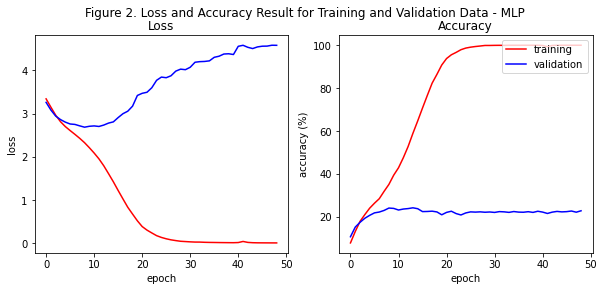

In [ ]:
graph_result(ROOT_WORK+'/results/MLPclassifier50epochs.pt',"Figure 2. Loss and Accuracy Result for Training and Validation Data - MLP")

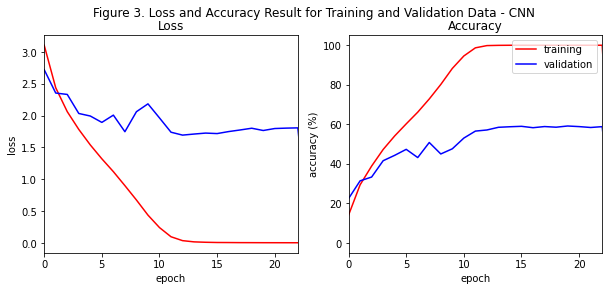

In [ ]:
graph_result(ROOT_WORK+'/results/CNNclassifier50epochs512.pt',"Figure 3. Loss and Accuracy Result for Training and Validation Data - CNN")

#### **Comparison of Loss and Accuracy Movement**
1. Figure 2 shows that the loss function of vaidation data in MLP models only decrease in first 10 epoch but keep increasing after that. Subsequently, the accuracy is not improving after 10 epoch (still in 20%. This indicates that the models is not good enough.
2. Figure 3 shows that the loss function is decreasing and stops at 23th epoch, since the loss value reach 0.0. The accuracy are also increasing. However, it doesn't increase significantly after 10 epochs. This reflects that the models is already on its prime and reach the highest accuracy. On contrary, there is huge gap between training and validation. The huge gap indicates that the models is overfitting to training data. Therefore, the models need to be adjusted appropiately.

### 2.2 Generating confusion matrix and ROC curves [4 marks]


The following code is used for creating:
1. Confusion Matrix heatmap
2. Calculation of Accuracy, Precision, Recall, and ROC_AUC

  (The Precision, Recall, and ROC AUC will be displayed with heatmap.)
3. Top-5 ROC_AUC curve


In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve,auc
import seaborn as sn
import pandas as pd
def accuracy(cnfm):
    return cnfm.trace()/cnfm.sum((0,1))
def recalls(cnfm):
    return np.diag(cnfm)/cnfm.sum(1)
def precisions(cnfm):
    return np.diag(cnfm)/cnfm.sum(0)
classes=np.arange(0,30)
report={}
def confusion_mat(net, results_path, classes, data_loader,title_):
  net=net.cuda()
  d = torch.load(results_path)
  net.load_state_dict(d["model_state_dict"])
  nclasses = classes.shape[0]
  cnfm = np.zeros((nclasses,nclasses),dtype=int)
  y_true=[]
  y_pred=[]
  y_pred_score=[]
  print(title_)
  net.eval()
  with torch.no_grad():
    for data in data_loader:
        images, labels = data
        images=images.cuda()
        labels=labels.cuda()
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(predicted.cpu().tolist())

        scores_=torch.nn.functional.softmax(outputs,1)
        y_scores=[i.tolist() for i in scores_]
        y_pred_score.extend(y_scores)
        for i in range(labels.size(0)):
            cnfm[labels[i].item(),predicted[i].item()] += 1
  plt.figure(figsize=(9,8))
  sn.heatmap(cnfm, cmap='viridis',vmax=100,vmin=0)
  plt.title('A. Confusion Matrix')
  #plt.colorbar(cnfm)
  plt.show()
  print(f"Accuracy: {accuracy(cnfm) :.1%}")
  r = recalls(cnfm)
  p = precisions(cnfm)
  fpr = dict()
  tpr = dict()
  roc_auc = dict()
  label_binarizer = LabelBinarizer().fit(y_true)
  y_test = label_binarizer.transform(y_pred)
  y_pred_score=np.array(y_pred_score)
  for i in range(0,nclasses):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

  dict_report={'accuracy':accuracy(cnfm),'precision':np.mean(p),'recalls':np.mean(r)}
  #for i in range(nclasses):
  #  print(f"Class {classes[i]} : Precision {p[i] :.1%}  Recall {r[i] :.1%}  ROC_AUC: {roc_auc[i]: .3}")

  report=pd.DataFrame(list(zip(p,r,list(roc_auc.values()))),
                      index=classes,columns=['Precission','Recall','ROC_AUC OvR'])
  plt.figure(figsize=(10,4))
  sn.heatmap(report.transpose(),vmin=0,vmax=1,cmap='viridis').set(title='B. Classification Report: ',xlabel='Classes')
  plt.show()
  best_five=np.array(list(roc_auc.values()))
  best_=best_five.argsort()[:5]
  fig,ax=plt.subplots(ncols=5,figsize=(15,3))
  iter_=0
  print('C. Top 5 class ROC-AUC OvR')
  for i in best_:
    ax[iter_].plot(fpr[i], tpr[i], label='ROC curve (area = %0.2f)' % roc_auc[i])
    ax[iter_].plot([0, 1], [0, 1], 'k--')
    ax[iter_].set_xlim([0.0, 1.0])
    ax[iter_].set_ylim([0.0, 1.05])
    ax[iter_].set_xlabel('FPR')
    ax[iter_].set_ylabel('TPR')
    ax[iter_].set_title('ROC class='+str(i))
    iter_=iter_+1
  plt.show()
  return dict_report

#### Confusion Matrix and Classification Report: CNN
Since the CNN models outperforms the MLP models, the following report are calculated using CNN models

Figure 4. Classification Report on Training data  -CNN 


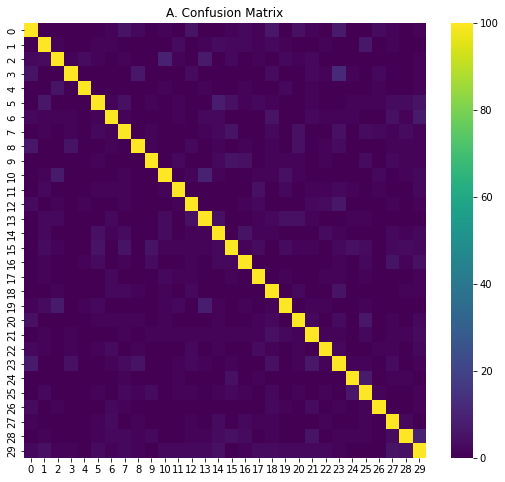

Accuracy: 91.8%


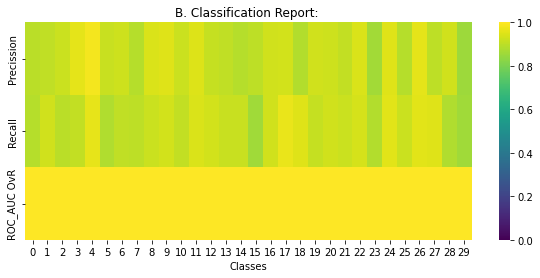

C. Top 5 class ROC-AUC OvR


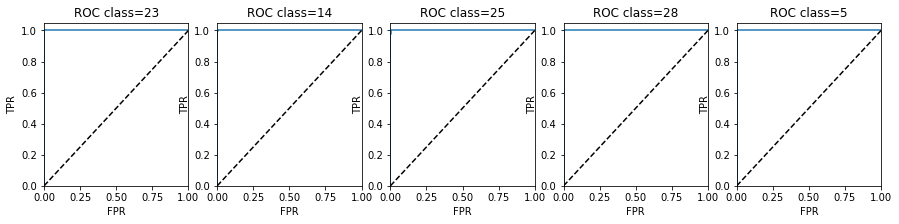

In [ ]:
net_cnn = NetCNN()
results_path_CNN=ROOT_WORK+'/results/CNNclassifier50epochs512.pt'
y_CNN_base_train=confusion_mat(net_cnn,results_path_CNN,classes,train_dl,'Figure 4. Classification Report on Training data  -CNN ')

Figure 5. Classification Report on Validation data  -CNN 


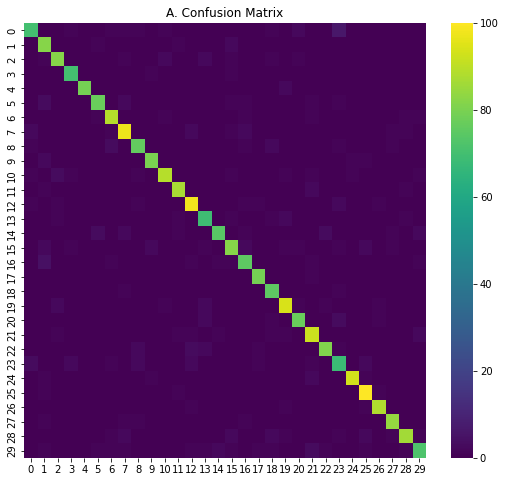

Accuracy: 91.5%


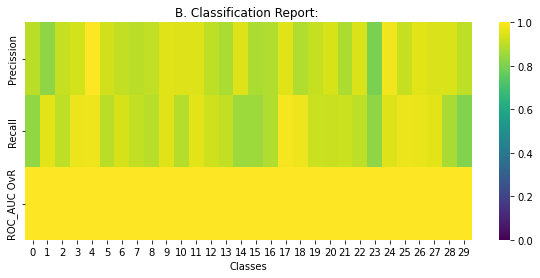

C. Top 5 class ROC-AUC OvR


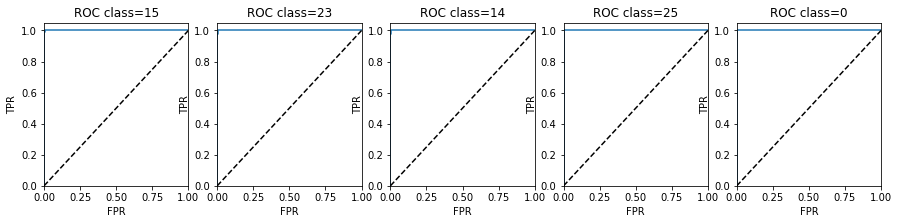

In [ ]:
y_CNN_base_valid=confusion_mat(net_cnn,results_path_CNN,classes,valid_dl,'Figure 5. Classification Report on Validation data  -CNN ')

In [ ]:
report[0]=y_CNN_base_train
report[0]['data']='Based on Training data'
report[0]['model']='CNN based'
report[1]=y_CNN_base_valid
report[1]['data']='Based on Validation data'
report[1]['model']='CNN based'

As shown in the report that the accuracy of CNN data is quite high (91%) for both training and validation data. All diagonals shows yellow colour, which is color symbol for accuracy above 90%.

Furthermore, precision and recalls are also high (indicated by yellow-greenish colour). Suprisingly, the ROC-AUC OvR for all class are 1, indicates that the models is good enough in distinguishing one class vs rest. It also indicated by the top 5 ROC-AUC curve

However, this models is quite overfitting and not generalized since it only produce 50% in Kaggle test data. Hence, several adjustment strategy is conducted.

### 2.3 Strategies for tackling overfitting (9 marks)

Several strategies are performing for tacking overfitting, as follows:
*   **2.3.1** Data augmentation
*   **2.3.2** Dropout
*   **2.3.3** Hyperparameter tuning (changing learning rate)

#### 2.3.1 Data augmentation

> This sections describe the data augmentation strategies used for handling overfitting problem, such as:
1. Random Prespective: create random prespective of the data
2. Random Resized Crop: random crop the image and resize the cropped into following size
3. Random Horizontal Flip: random flip the image horizontally
4. Random Vertical Flip: random flip the image vertically
5. Color Jitter: change the color based on brightness and hue
6. Random Adjust Sharpness : random adjust the sharpness of the images


In [ ]:
transform_aug= transforms.Compose([
    transforms.RandomPerspective(distortion_scale=0.7, p=0.2), ## Random Prespective
    transforms.RandomResizedCrop(size=(64),scale=(0.5,1)), ## Crop and Resize the crop file
    transforms.RandomHorizontalFlip(p=0.5), ## Random Horizontal Flip
    transforms.RandomVerticalFlip(p=0.5),   ## Random Vertical Flip
    transforms.ColorJitter(brightness=.5, hue=.3), ## Random Color Jitter
    transforms.RandomAdjustSharpness(sharpness_factor=2), ## Random Adjust Sharpness
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])

])

In [ ]:
dataset_aug = ImageFolder(root=train_path,transform=transform_aug)
# create the dataset
train_ds_aug, valid_ds_aug = torch.utils.data.random_split(dataset_aug, [0.8, 0.2])
# create the dataloader
train_dl_aug = DataLoader(train_ds_aug,batch_size=64,shuffle=True, num_workers=2)
valid_dl_aug = DataLoader(valid_ds_aug,batch_size=64,shuffle=True, num_workers=2)

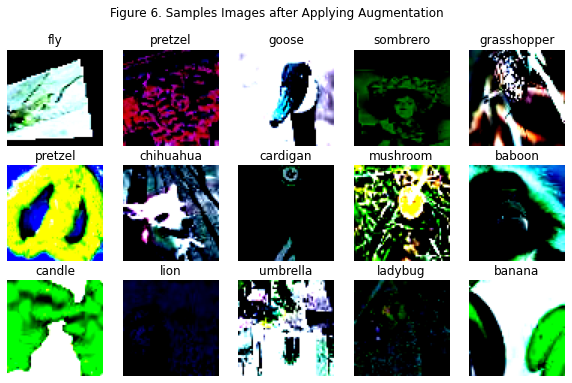

In [ ]:
figure= plt.figure(figsize=(10, 6))
cols, rows = 5, 3
labels_map=dataset.class_to_idx

#get one batch
train_features, train_labels = next(iter(train_dl_aug))
for i in range(1, cols * rows + 1):
  img = train_features[i].squeeze()
  label = train_labels[i]
  figure.add_subplot(rows, cols, i)
  plt.title(list(labels_map.keys())[list(labels_map.values()).index(label.item())])
  img = np.transpose(img.numpy(),(1,2,0))
  plt.imshow(img.squeeze())
  plt.axis('off')

figure.suptitle('Figure 6. Samples Images after Applying Augmentation')
plt.show()

As illustrated in the Figure 6, several images are transformed randomly following the augmentation strategy.



**Training using Data Augmentation**

In [ ]:
net_cnn_aug=NetCNN()
results_path_CNN_aug=ROOT_WORK+'/results/CNNclassifier50epochs_aug.pt'
training_netlayer(net_cnn_aug, nepochs, results_path_CNN_aug, train_dl_aug,valid_dl_aug,0.001,device,0.9,False)

Saving a checkpoint - epoch: 5 training loss:  2.692 training accuracy:  22.251%  valid loss:  2.656 valid accuracy: 22.929%
Saving a checkpoint - epoch: 10 training loss:  2.296 training accuracy:  32.797%  valid loss:  2.391 valid accuracy: 31.395%
Saving a checkpoint - epoch: 15 training loss:  2.035 training accuracy:  40.563%  valid loss:  2.260 valid accuracy: 35.223%
Saving a checkpoint - epoch: 20 training loss:  1.859 training accuracy:  45.205%  valid loss:  2.124 valid accuracy: 39.317%
Saving a checkpoint - epoch: 25 training loss:  1.694 training accuracy:  49.926%  valid loss:  1.836 valid accuracy: 45.918%
Saving a checkpoint - epoch: 30 training loss:  1.567 training accuracy:  52.771%  valid loss:  1.917 valid accuracy: 47.117%
Saving a checkpoint - epoch: 35 training loss:  1.456 training accuracy:  56.410%  valid loss:  1.756 valid accuracy: 48.195%
Saving a checkpoint - epoch: 40 training loss:  1.345 training accuracy:  59.141%  valid loss:  1.719 valid accuracy: 5

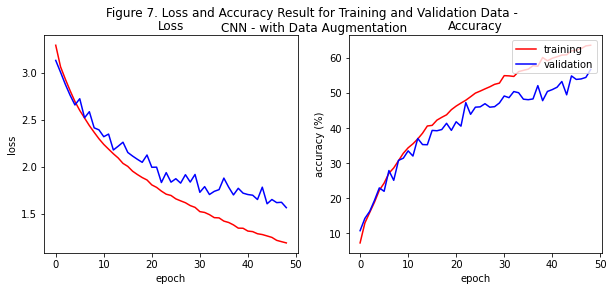

In [ ]:
results_path_CNN_aug=ROOT_WORK+'/results/CNNclassifier50epochs_aug.pt'
graph_result(results_path_CNN_aug,"Figure 7. Loss and Accuracy Result for Training and Validation Data - \nCNN - with Data Augmentation")

As shown in Figure 7. It's clear that the validation loss is kept decresing and the accuracy is also kept increasing. This can be good sign for improvement in handling the overfitting in the data. Thus, the augmentation data are use for training the data.

#### 2.3.2 Dropout

In this part, the Dropout layer are introduced after Fully Connected Layer. The dropout layer can be used for randomly ignore the neuron. This can be used for generalizing the model as well as tackle overfiiting. The randomness are controlled via dropout rate parameters.

The following code are CNN network with dropout layer implementation.

In [ ]:
##### CNN MODEL with Dropout
## This code is CNN network configureation

class NetCNNDropout(nn.Module):
    def __init__(self, num_classes=30,dropout_r=0.25):
        super(NetCNNDropout, self).__init__()
        self.conv2_1=nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.conv2_2=nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2))

        self.conv2_3=nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU())

        self.conv2_4=nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2))

        self.conv2_5=nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU())

        self.conv2_6=nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU())

        self.conv2_7=nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2))

        self.conv2_8=nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())

        self.conv2_9=nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            )

        self.conv2_10=nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2))

        self.flatten=nn.Flatten()
        self.fc1=nn.Sequential(
            nn.Linear(512*4*4,4096),
            nn.ReLU(),
            nn.Dropout(dropout_r),
            nn.Linear(4096,4096),
            nn.ReLU(),
            nn.Dropout(dropout_r),
            nn.Linear(4096,num_classes)
        )
    def forward(self, x):
        x = self.conv2_1(x)
        x = self.conv2_2(x)
        x = self.conv2_3(x)
        x = self.conv2_4(x)
        x = self.conv2_5(x)
        x = self.conv2_6(x)
        x = self.conv2_7(x)
        x = self.conv2_8(x)
        x = self.conv2_9(x)
        x = self.conv2_10(x)
        x = self.flatten(x)
        x = self.fc1(x)
        return x
net_ = NetCNNDropout(dropout_r=0.25)
y_=sum(p.numel() for p in net_.parameters())
print(f'Number of Paramaters in this CNN network with dropout: {y_}')

Number of Paramaters in this CNN network with dropout: 58103390


For determining the appropriate dropout rate, we compare model with dropout rate 0.25 and 0.5

##### Training Dropout Rate 0.25

In [ ]:
net_cnn_drop = NetCNNDropout(dropout_r=0.25)
results_path_CNN_d=ROOT_WORK+'/results/CNNclassifier50epochs_25d.pt'
training_netlayer(net_cnn_drop, 50, results_path_CNN_d, train_dl_aug,valid_dl_aug,0.001,device,0.9,True)

Resuming Training process- epoch: 27 training loss:  1.762 training accuracy:  47.880%  valid loss:  1.988 valid accuracy: 43.350%
Saving a checkpoint - epoch: 30 training loss:  1.685 training accuracy:  49.750%  valid loss:  1.675 valid accuracy: 49.673%
Saving a checkpoint - epoch: 35 training loss:  1.571 training accuracy:  53.227%  valid loss:  1.976 valid accuracy: 42.926%
Saving a checkpoint - epoch: 40 training loss:  1.471 training accuracy:  55.517%  valid loss:  1.703 valid accuracy: 49.952%
Saving a checkpoint - epoch: 45 training loss:  1.386 training accuracy:  58.281%  valid loss:  1.664 valid accuracy: 51.357%
Saving a checkpoint - epoch: 49 training loss:  1.323 training accuracy:  59.834%  valid loss:  1.676 valid accuracy: 52.023%



##### Training Dropout Rate 0.5

In [ ]:
net_cnn_drop = NetCNNDropout(dropout_r=0.5)
results_path_CNN_d=ROOT_WORK+'/results/CNNclassifier50epochs_50d.pt'
training_netlayer(net_cnn_drop, 50, results_path_CNN_d, train_dl_aug,valid_dl_aug,0.001,device,0.9,True)

Resuming Training process- epoch: 37 training loss:  1.637 training accuracy:  51.402%  valid loss:  1.811 valid accuracy: 47.469%
Saving a checkpoint - epoch: 40 training loss:  1.603 training accuracy:  52.123%  valid loss:  1.674 valid accuracy: 50.569%
Saving a checkpoint - epoch: 45 training loss:  1.515 training accuracy:  54.866%  valid loss:  1.693 valid accuracy: 49.794%
Saving a checkpoint - epoch: 49 training loss:  1.461 training accuracy:  56.629%  valid loss:  1.543 valid accuracy: 54.566%


##### Comparison of Two Dropout Rate

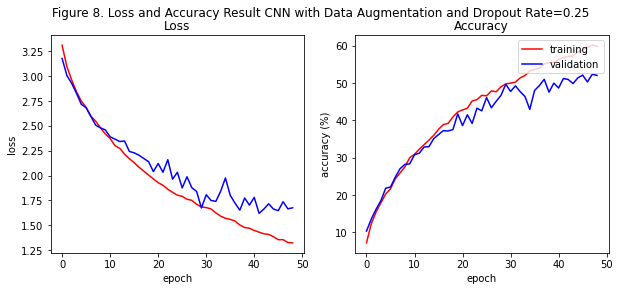

In [ ]:
results_path_CNN_d=ROOT_WORK+'/results/CNNclassifier50epochs_25d.pt'
graph_result(results_path_CNN_d,"Figure 8. Loss and Accuracy Result CNN with Data Augmentation and Dropout Rate=0.25")

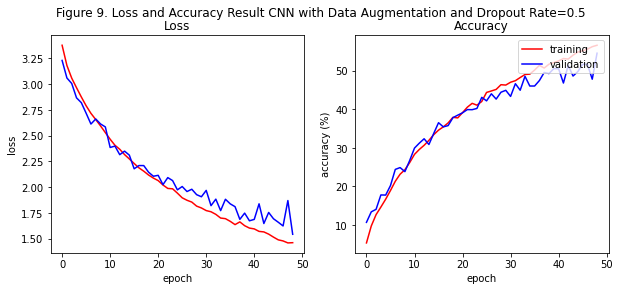

In [ ]:
results_path_CNN_d=ROOT_WORK+'/results/CNNclassifier50epochs_50d.pt'
graph_result(results_path_CNN_d,"Figure 9. Loss and Accuracy Result CNN with Data Augmentation and Dropout Rate=0.5")

Both Figure 8 and Figure 9 indicates the decreasing validation loss and increasing accuracy for every epochs. Compare with Figure 7, the gap of validation and training result is quite small which indicate that the model is good. Although the accuracy of CNN model with dropout rate=0.5 is quite higher in last epoch, two models is still improving. Hence, the dropout rate will be choosen in the next section after evaluating learning rate changes.

#### 2.3.3 Hyper Parameter Tuning


This section perform selection of learning rate. Since base model using 0.001, we will select another options for learning rate from [0.1,0.01,0.0001]. We also conduct the tuning twice (first with dropout rate=0.5 then dropout rate=0.25).

##### Tuning Learning Rate for Dropout Rate 0.25

In [ ]:
for i in [0.1, 0.01,0.0001]:
  print('===========================================================')
  print(f'Train for learning rate:{i}')
  k=str(i).replace('.','-')
  results_path_CNN_ht=ROOT_WORK+'/results/CNNclassifier50epochs_'+k+'_50d.pt'
  net_cnn_ht = NetCNNDropout(dropout_r=0.5)
  if os.path.exists(results_path_CNN_ht):
    training_netlayer(net_cnn_ht, 50, results_path_CNN_ht, train_dl_aug,valid_dl_aug,i,device,0.9,True)
  else:
    training_netlayer(net_cnn_ht, 50, results_path_CNN_ht, train_dl_aug,valid_dl_aug,i,device,0.9,False)

Train for learning rate:0.1
Saving a checkpoint - epoch: 5 training loss:  3.401 training accuracy:  3.936%  valid loss:  3.396 valid accuracy: 4.227%
Saving a checkpoint - epoch: 10 training loss:  3.352 training accuracy:  5.406%  valid loss:  3.394 valid accuracy: 4.978%
Saving a checkpoint - epoch: 15 training loss:  3.233 training accuracy:  7.329%  valid loss:  3.232 valid accuracy: 7.413%
Saving a checkpoint - epoch: 20 training loss:  3.195 training accuracy:  8.358%  valid loss:  3.174 valid accuracy: 9.799%
Saving a checkpoint - epoch: 25 training loss:  3.150 training accuracy:  9.409%  valid loss:  3.115 valid accuracy: 11.495%
Saving a checkpoint - epoch: 30 training loss:  3.094 training accuracy:  11.560%  valid loss:  3.069 valid accuracy: 12.464%
Saving a checkpoint - epoch: 35 training loss:  3.058 training accuracy:  12.688%  valid loss:  3.028 valid accuracy: 12.803%
Saving a checkpoint - epoch: 40 training loss:  2.969 training accuracy:  14.648%  valid loss:  2.96

##### Tuning Learning Rate for Dropout Rate 0.5

In [ ]:
for i in [0.1, 0.01,0.0001]:
  print('===========================================================')
  print(f'Train for learning rate:{i}')
  k=str(i).replace('.','-')
  results_path_CNN_ht=ROOT_WORK+'/results/CNNclassifier50epochs_'+k+'_25d.pt'
  net_cnn_ht = NetCNNDropout(dropout_r=0.25)
  if os.path.exists(results_path_CNN_ht):
    training_netlayer(net_cnn_ht, 50, results_path_CNN_ht, train_dl_aug,valid_dl_aug,i,device,0.9,True)
  else:
    training_netlayer(net_cnn_ht, 50, results_path_CNN_ht, train_dl_aug,valid_dl_aug,i,device,0.9,False)

Train for learning rate:0.1
Resuming Training process- epoch: 40 training loss:  2.330 training accuracy:  33.977%  valid loss:  2.382 valid accuracy: 31.117%
Saving a checkpoint - epoch: 45 training loss:  2.244 training accuracy:  35.645%  valid loss:  2.222 valid accuracy: 35.780%
Saving a checkpoint - epoch: 49 training loss:  2.118 training accuracy:  38.680%  valid loss:  2.159 valid accuracy: 38.784%
Train for learning rate:0.01
Saving a checkpoint - epoch: 5 training loss:  2.796 training accuracy:  18.941%  valid loss:  2.776 valid accuracy: 19.186%
Saving a checkpoint - epoch: 10 training loss:  2.419 training accuracy:  30.535%  valid loss:  2.378 valid accuracy: 30.039%
Saving a checkpoint - epoch: 15 training loss:  2.156 training accuracy:  36.874%  valid loss:  2.497 valid accuracy: 32.328%
Saving a checkpoint - epoch: 20 training loss:  1.974 training accuracy:  42.243%  valid loss:  2.026 valid accuracy: 41.352%
Saving a checkpoint - epoch: 25 training loss:  1.813 tra

##### Evaluation of Tuning Learning Rate

A. For Dropout 0.25

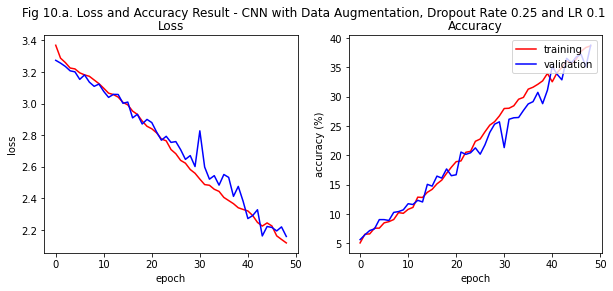

In [ ]:
net_cnn_drop = NetCNNDropout(dropout_r=0.25)
results_path_CNN_d=ROOT_WORK+'/results/CNNclassifier50epochs_0-1_25d.pt'
graph_result(results_path_CNN_d,"Fig 10.a. Loss and Accuracy Result - CNN with Data Augmentation, Dropout Rate 0.25 and LR 0.1")

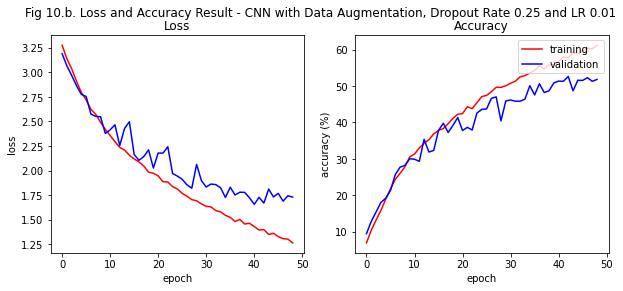

In [ ]:
net_cnn_drop = NetCNNDropout(dropout_r=0.25)
results_path_CNN_d=ROOT_WORK+'/results/CNNclassifier50epochs_0-01_25d.pt'
graph_result(results_path_CNN_d,"Fig 10.b. Loss and Accuracy Result - CNN with Data Augmentation, Dropout Rate 0.25 and LR 0.01")

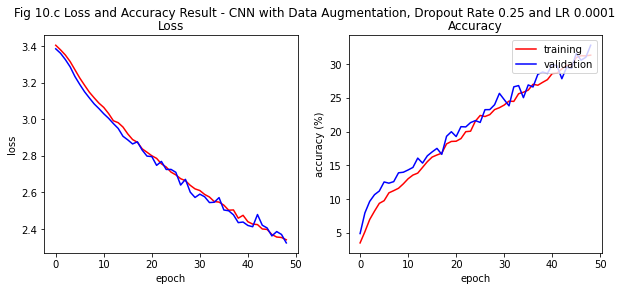

In [ ]:
net_cnn_drop = NetCNNDropout(dropout_r=0.25)
results_path_CNN_d=ROOT_WORK+'/results/CNNclassifier50epochs_0-0001_25d.pt'
graph_result(results_path_CNN_d,"Fig 10.c Loss and Accuracy Result - CNN with Data Augmentation, Dropout Rate 0.25 and LR 0.0001")

Figure 10.a, 10.b, and 10.c show the Los and Accuracy for each epoch following the tuning scenario. At glance, smller gap of validation and training are noticed in Figure 10.a and 10.c However, it is also shown that the loss value in last epoch is quite higher and the accuracy is quite lower comparing Figure 10.b or even Figure 8. This can be indicated the higher cost of computations. Besides that, the graph is quite straight until 50 epoch and hard to converges which also support the higher cost of computation.

B. For Dropout 0.5

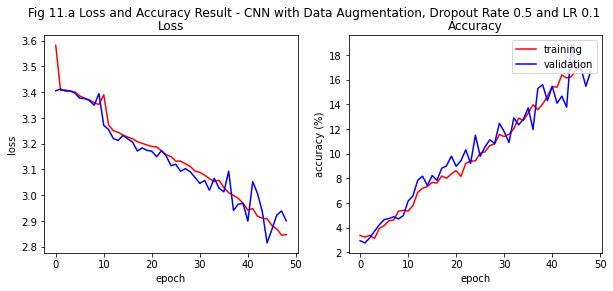

In [ ]:
net_cnn_drop = NetCNNDropout(dropout_r=0.5)
results_path_CNN_d=ROOT_WORK+'/results/CNNclassifier50epochs_0-1_50d.pt'
graph_result(results_path_CNN_d,"Fig 11.a Loss and Accuracy Result - CNN with Data Augmentation, Dropout Rate 0.5 and LR 0.1")

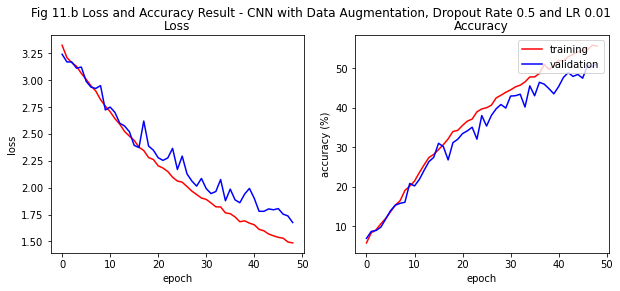

In [ ]:
net_cnn_drop = NetCNNDropout(dropout_r=0.5)
results_path_CNN_d=ROOT_WORK+'/results/CNNclassifier50epochs_0-01_50d.pt'
graph_result(results_path_CNN_d,"Fig 11.b Loss and Accuracy Result - CNN with Data Augmentation, Dropout Rate 0.5 and LR 0.01")

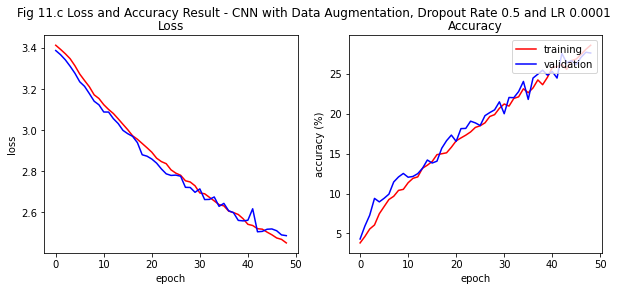

In [ ]:
net_cnn_drop = NetCNNDropout(dropout_r=0.5)
results_path_CNN_d=ROOT_WORK+'/results/CNNclassifier50epochs_0-0001_50d.pt'
graph_result(results_path_CNN_d,"Fig 11.c Loss and Accuracy Result - CNN with Data Augmentation, Dropout Rate 0.5 and LR 0.0001")

Similarly with figure 10, figure 11.a and 11.c show that the loss value in last epoch is quite higher and the accuracy is quite lower comparing Figure 11.b or even Figure 9. Hence the computation cost of using learning rate 0.1 and 0.0001 is quite expensive.

#### Classification Evaluation Report

The following figure descripte the classification evaluation report for all strategies in handling overfitting.

##### Classification Report on Data Augmentation



Fig 12.a. Confussion Matrix of Validation data  -CNN -
Data Augmentation


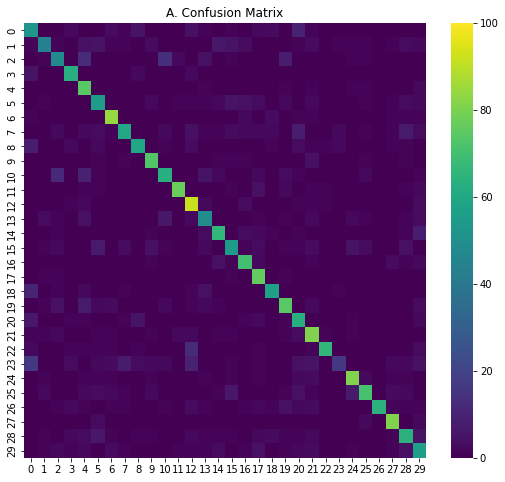

Accuracy: 71.6%


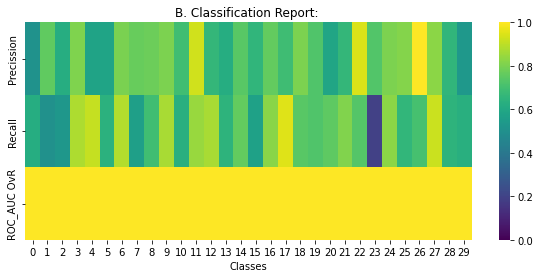

C. Top 5 class ROC-AUC OvR


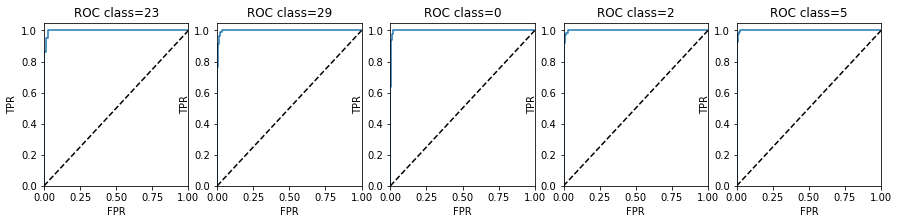

In [ ]:
print('\n==================================================\n')
net_cnn_aug=NetCNN()
results_path_CNN_aug=ROOT_WORK+'/results/CNNclassifier50epochs_aug.pt'
y_aug=confusion_mat(net_cnn_aug,results_path_CNN_aug,classes,valid_dl,'Fig 12.a. Confussion Matrix of Validation data  -CNN -\nData Augmentation')

##### Classification Report on Dropout 0.25



Fig 12.b. Confussion Matrix of Validation data  -CNN -
Data Augmentation
Dropout Rate=0.25


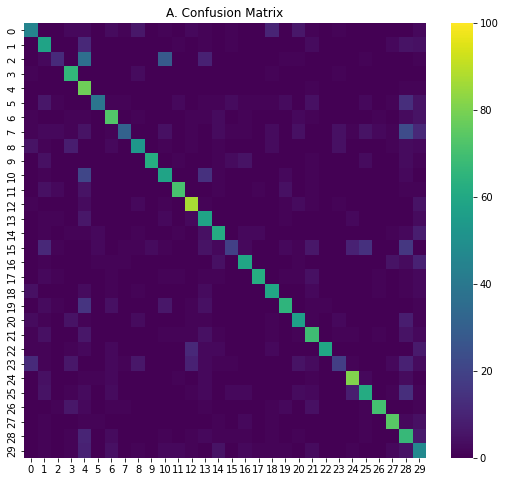

Accuracy: 63.6%


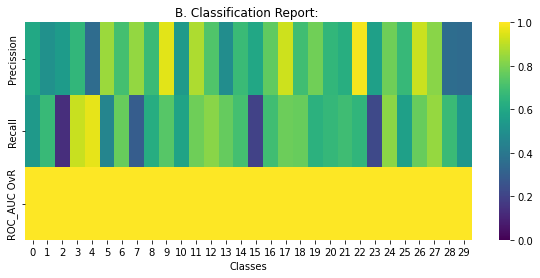

C. Top 5 class ROC-AUC OvR


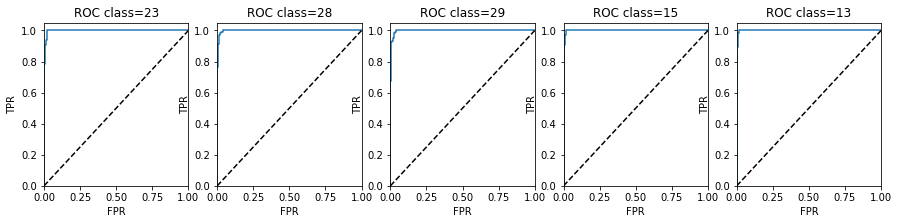

In [ ]:
print('\n==================================================\n')
net_cnn=NetCNNDropout(dropout_r=0.25)
results_path_CNN=ROOT_WORK+'/results/CNNclassifier50epochs_25d.pt'
y_d25=confusion_mat(net_cnn,results_path_CNN,classes,valid_dl,'Fig 12.b. Confussion Matrix of Validation data  -CNN -\nData Augmentation\nDropout Rate=0.25')

##### Classification Report on Dropout Rate 0.25 and LR 0.1



Fig 12.c. Confussion Matrix of Validation data  -CNN -
Data Augmentation
Dropout Rate=0.25
 LR 0.1


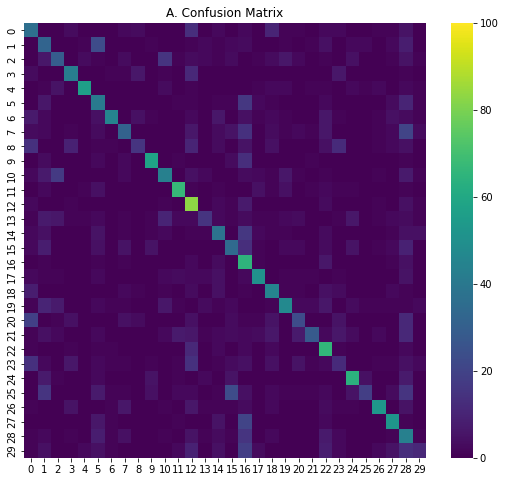

Accuracy: 46.0%


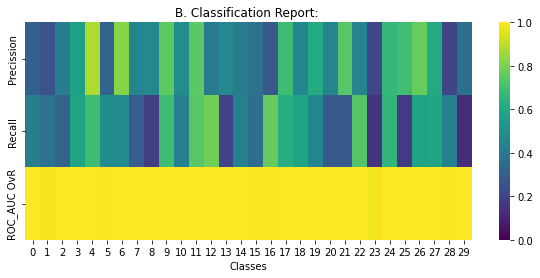

C. Top 5 class ROC-AUC OvR


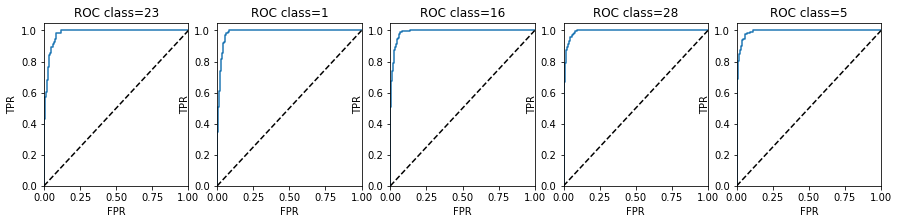

In [ ]:
print('\n==================================================\n')
net_cnn=NetCNNDropout(dropout_r=0.25)
results_path_CNN=ROOT_WORK+'/results/CNNclassifier50epochs_0-1_25d.pt'
y_d25_01=confusion_mat(net_cnn,results_path_CNN,classes,valid_dl,'Fig 12.c. Confussion Matrix of Validation data  -CNN -\nData Augmentation\nDropout Rate=0.25\n LR 0.1')

##### Classification Report on Dropout Rate 0.25 and LR 0.01



Fig 12.d. Confussion Matrix of Validation data  -CNN -
Data Augmentation
Dropout Rate=0.25
 LR 0.01


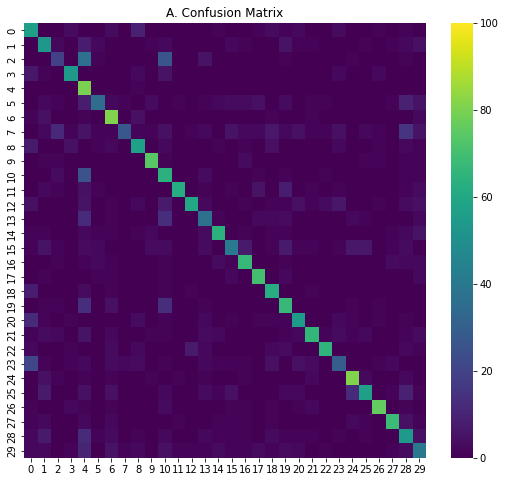

Accuracy: 63.7%


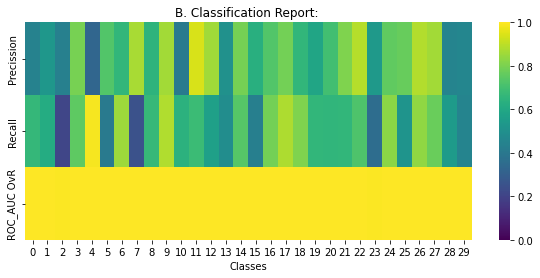

C. Top 5 class ROC-AUC OvR


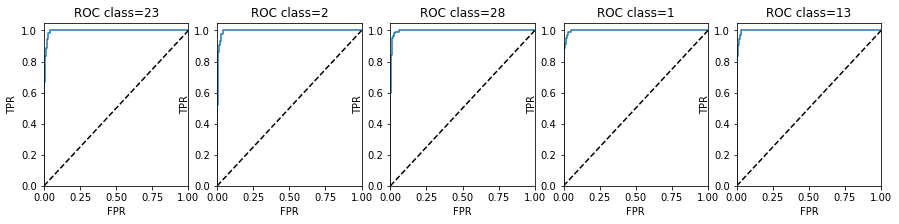

In [ ]:
print('\n==================================================\n')
net_cnn=NetCNNDropout(dropout_r=0.25)
results_path_CNN=ROOT_WORK+'/results/CNNclassifier50epochs_0-01_25d.pt'
y_d25_001=confusion_mat(net_cnn,results_path_CNN,classes,valid_dl,'Fig 12.d. Confussion Matrix of Validation data  -CNN -\nData Augmentation\nDropout Rate=0.25\n LR 0.01')

##### Classification Report on Dropout Rate 0.25 and LR 0.0001



Fig 12.e. Confussion Matrix of Validation data  -CNN -
Data Augmentation
Dropout Rate=0.25
 LR 0.0001


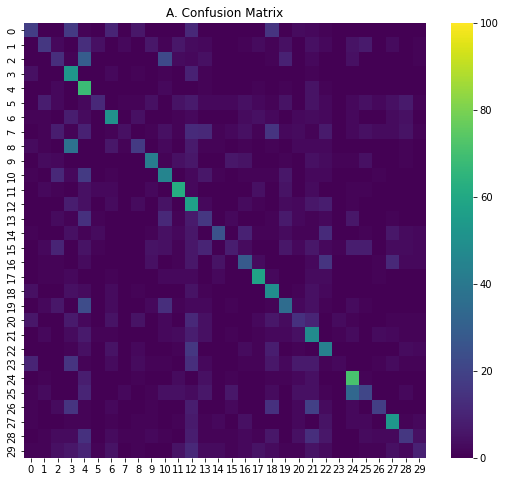

Accuracy: 35.9%


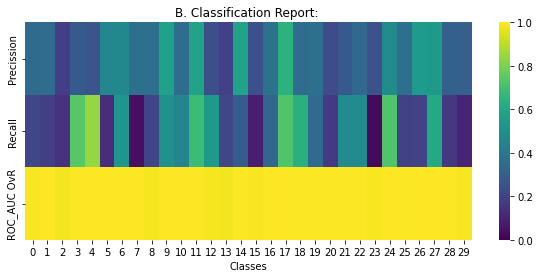

C. Top 5 class ROC-AUC OvR


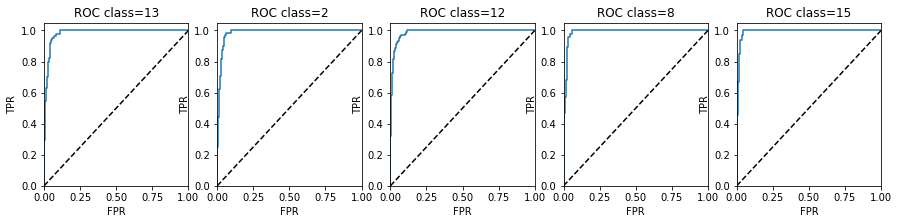

In [ ]:
print('\n==================================================\n')
net_cnn=NetCNNDropout(dropout_r=0.25)
results_path_CNN=ROOT_WORK+'/results/CNNclassifier50epochs_0-0001_25d.pt'
y_d25_00001=confusion_mat(net_cnn,results_path_CNN,classes,valid_dl,'Fig 12.e. Confussion Matrix of Validation data  -CNN -\nData Augmentation\nDropout Rate=0.25\n LR 0.0001')

##### Classtfication Report on Dropout Rate 0.5



Fig 12.f. Confussion Matrix of Validation data  -CNN -
Data Augmentation
Dropout Rate=0.50


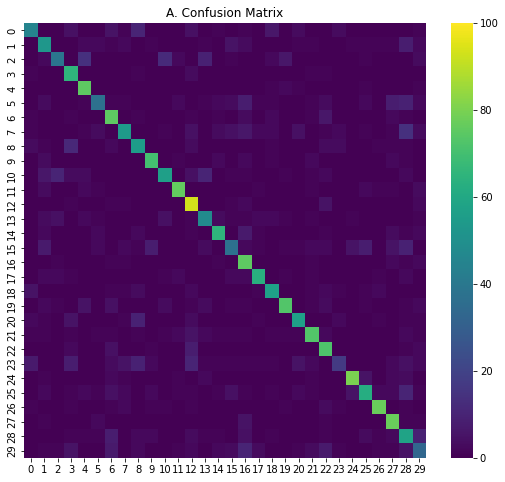

Accuracy: 67.3%


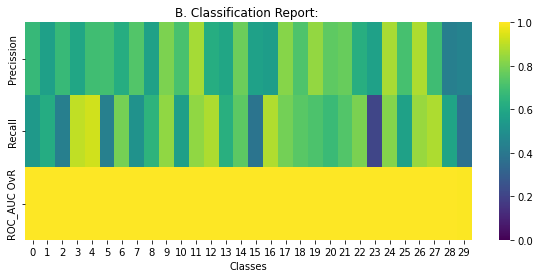

C. Top 5 class ROC-AUC OvR


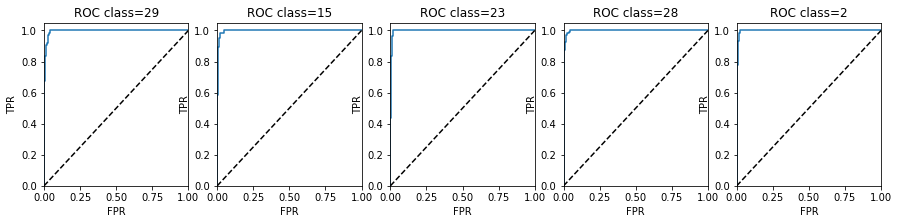

In [ ]:
print('\n==================================================\n')
net_cnn=NetCNNDropout(dropout_r=0.5)
results_path_CNN=ROOT_WORK+'/results/CNNclassifier50epochs_50d.pt'
y_d50=confusion_mat(net_cnn,results_path_CNN,classes,valid_dl,'Fig 12.f. Confussion Matrix of Validation data  -CNN -\nData Augmentation\nDropout Rate=0.50')

##### Classification Report on Dropout Rate 0.5 and LR 0.1



Fig 12.g. Confussion Matrix of Validation data  -CNN -
Data Augmentation
Dropout Rate=0.50 
LR=0.1


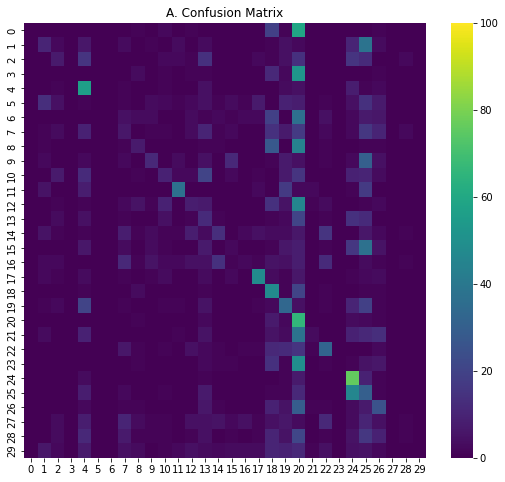

Accuracy: 20.1%


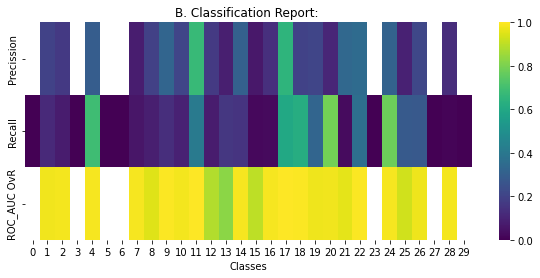

C. Top 5 class ROC-AUC OvR


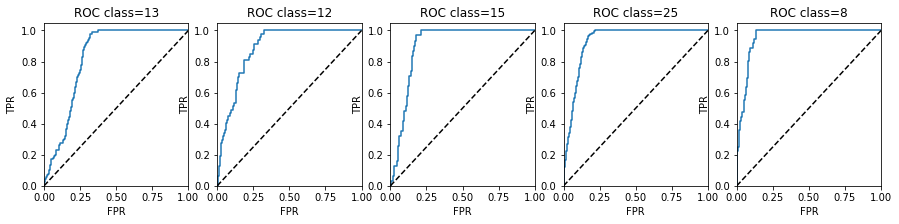

In [ ]:
print('\n==================================================\n')
net_cnn=NetCNNDropout(dropout_r=0.5)
results_path_CNN=ROOT_WORK+'/results/CNNclassifier50epochs_0-1_50d.pt'
y_d50_01=confusion_mat(net_cnn,results_path_CNN,classes,valid_dl,'Fig 12.g. Confussion Matrix of Validation data  -CNN -\nData Augmentation\nDropout Rate=0.50 \nLR=0.1')

##### Classification Report on Dropout Rate 0.5 and LR 0.01



Fig 12.g. Confussion Matrix of Validation data  -CNN -
Data Augmentation
Dropout Rate=0.50 
LR=0.01


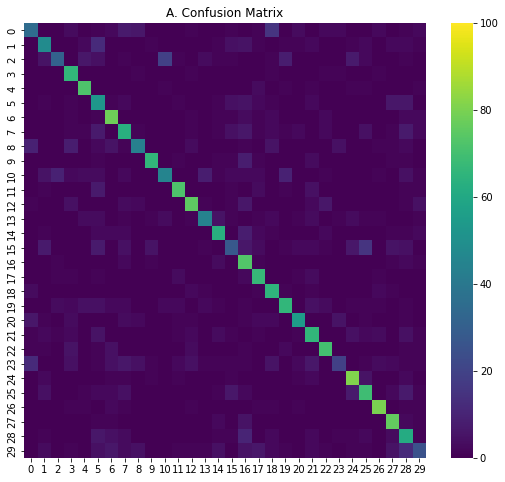

Accuracy: 65.0%


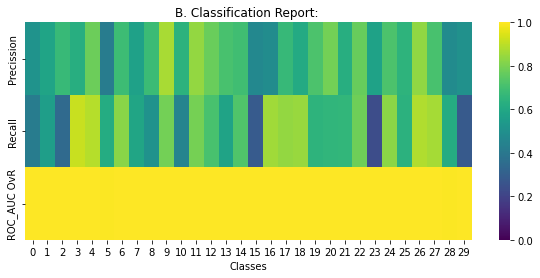

C. Top 5 class ROC-AUC OvR


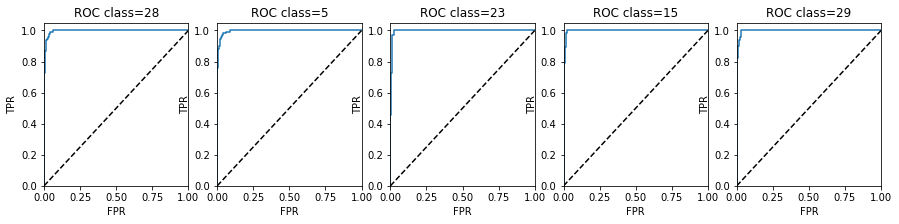

In [ ]:
print('\n==================================================\n')
net_cnn=NetCNNDropout(dropout_r=0.5)
results_path_CNN=ROOT_WORK+'/results/CNNclassifier50epochs_0-01_50d.pt'
y_d50_001=confusion_mat(net_cnn,results_path_CNN,classes,valid_dl,'Fig 12.h. Confussion Matrix of Validation data  -CNN -\nData Augmentation\nDropout Rate=0.50 \nLR=0.01')

##### Classification Report on Dropout Rate 0.5 and LR 0.0001



Fig 12.i. Confussion Matrix of Validation data  -CNN -
Data Augmentation
Dropout Rate=0.50 
LR=0.0001


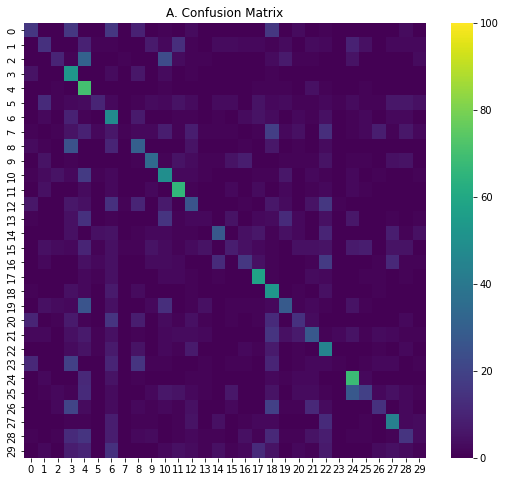

Accuracy: 32.1%


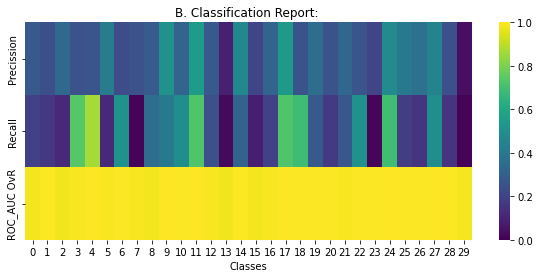

C. Top 5 class ROC-AUC OvR


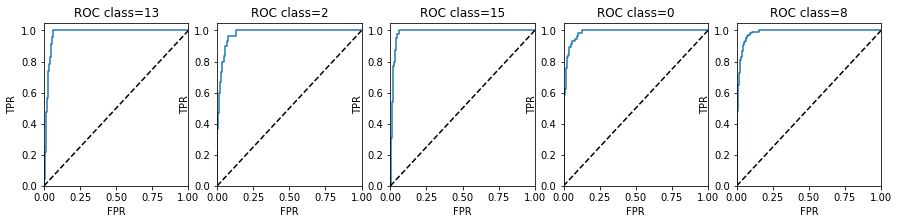

In [ ]:
print('\n==================================================\n')
net_cnn=NetCNNDropout(dropout_r=0.5)
results_path_CNN=ROOT_WORK+'/results/CNNclassifier50epochs_0-0001_50d.pt'
y_d50_0001=confusion_mat(net_cnn,results_path_CNN,classes,valid_dl,'Fig 12.i. Confussion Matrix of Validation data  -CNN -\nData Augmentation\nDropout Rate=0.50 \nLR=0.0001')

#### Strategy Summary

It can be shown that accuracy from training data with augmentation without applying dropout is higher than the ones who applying the dropout. However, it can be explained. Due to implementation of dropout, the models need to be trained longer. Despite that, applying dropout still have beneficial aspect in generalizing the models. Additionally, comparing the gap of validation and training in loss and accuracy from each epoch (figure 7, 8, and 9), the gap is smaller when dropout layer is implemented.From this prespective, the dropout layer is still can be implemented with drawbacks to increase the epochs.

In addition to that, models with 0.001 as learning rate still outperform other models in term of accuracy. Subsequently, accuracy in application of the dropout rate= 0.25 is still higher than application of 0.5 as dropout rate.

Based on this approaches, the strategy for handling overfitting are:
1. Use the data augmentation in model training
2. Use dropout layer for generalizing the results
3. Use learning rate 0.001
4. Increase the epochs as drawback of implementation of dropout layer.

In [ ]:
import shutil
## Duplicate the best models into new ones
shutil.copy(ROOT_WORK+'/results/CNNclassifier50epochs_25d.pt',ROOT_WORK+'/results/CNNclassifier100epochs_25d.pt')

'/content/drive/MyDrive/Master in Leeds/Deep Learning/Assignment 1//results/CNNclassifier100epochs_25d.pt'

Resume the training

In [ ]:
results_path_CNN_ht=ROOT_WORK+'/results/CNNclassifier100epochs_25d.pt'
net_cnn_ht = NetCNNDropout(dropout_r=0.25)
training_netlayer(net_cnn_ht, 250, results_path_CNN_ht, train_dl_aug,valid_dl_aug,0.001,device,0.9,True)

Resuming Training process- epoch: 149 training loss:  0.513 training accuracy:  84.061%  valid loss:  1.458 valid accuracy: 63.445%
Saving a checkpoint - epoch: 150 training loss:  0.506 training accuracy:  83.796%  valid loss:  1.445 valid accuracy: 63.081%
Saving a checkpoint - epoch: 155 training loss:  0.483 training accuracy:  84.985%  valid loss:  1.542 valid accuracy: 61.131%
Saving a checkpoint - epoch: 160 training loss:  0.471 training accuracy:  84.618%  valid loss:  1.526 valid accuracy: 62.512%
Saving a checkpoint - epoch: 165 training loss:  0.438 training accuracy:  86.243%  valid loss:  1.498 valid accuracy: 62.900%
Saving a checkpoint - epoch: 170 training loss:  0.418 training accuracy:  86.862%  valid loss:  1.500 valid accuracy: 62.221%
Saving a checkpoint - epoch: 175 training loss:  0.422 training accuracy:  86.523%  valid loss:  1.530 valid accuracy: 64.099%
Saving a checkpoint - epoch: 180 training loss:  0.392 training accuracy:  87.629%  valid loss:  1.542 val

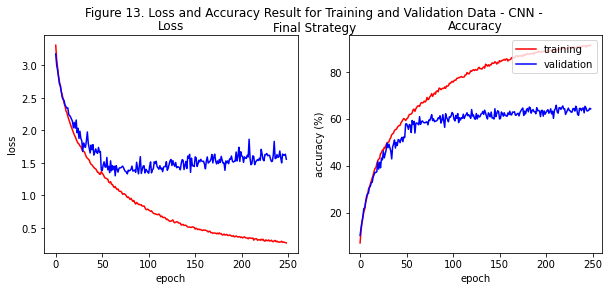



Figure 14. Classification Report


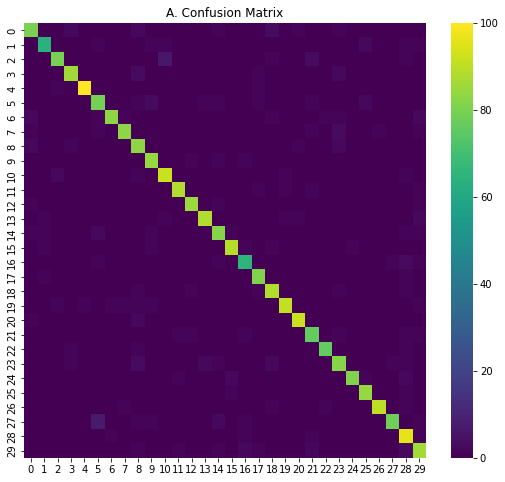

Accuracy: 93.1%


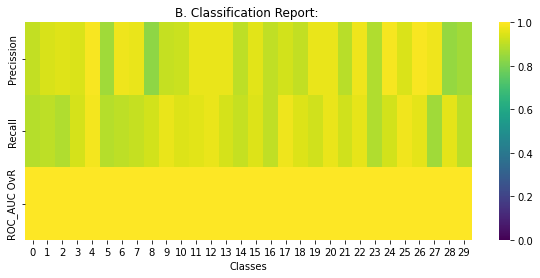

C. Top 5 class ROC-AUC OvR


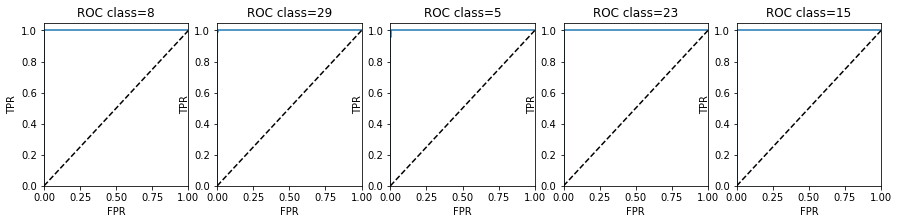

{'accuracy': 0.9311111111111111,
 'precision': 0.9328285677078323,
 'recalls': 0.9306878410606427}

In [ ]:
results_path_CNN_ht=ROOT_WORK+'/results/CNNclassifier100epochs_25d.pt'
net_cnn_ht = NetCNNDropout(dropout_r=0.25)
graph_result(results_path_CNN_ht,"Figure 13. Loss and Accuracy Result for Training and Validation Data - CNN -\nFinal Strategy")
print('\n==================================================\n')
confusion_mat(net_cnn_ht,results_path_CNN_ht,classes,valid_dl,'Figure 14. Classification Report')

Figure 13 shows that the accuracy and loss in training data is approaching convergence. However, the slow movement are shown in validation data.
Additionally, from the figure 14, it is clear that the accuracy is higher than previous options (around 93%).

## 3 Model testing [18 marks]



#### 3.1 Test class and predictions [10 marks]

The following code are used for creating Pytorch dataset to generate predictions of data test.

In [ ]:
# create dataset and dataloader for the test
#test_ds=LoadFromFolder(main_dir='/kaggle/input/comp5623m-artificial-intelligence/test_set/test_set/test_set',transform=transform_1)
test_ds=LoadFromFolder(main_dir='/content/drive/MyDrive/Master in Leeds/Deep Learning/Assignment 1/test_set/test_set',
                       transform=transform_1)
test_dl = DataLoader(test_ds, batch_size=64,
                        shuffle=True, num_workers=2)

#### 3.2 Prepare your submission and upload to Kaggle [8 marks]

Instructions:

Save all test predictions to a CSV file and submit it to the private class Kaggle competition. **Please save your test CSV file submissions using your student username (the one with letters, ie., ``sc15jb``, not the ID with only numbers)**, for example, `sc15jb.csv`. That will help us to identify your submissions.

The CSV file must contain only two columns: ‘Id’ and ‘Category’ (predicted class ID) as shown below:

```txt
Id,Category
28d0f5e9_373c.JPEG,2
bbe4895f_40bf.JPEG,18
```

Please note you will get marks for higher performance.

The ‘Id’ column should include the name of the image. It is important to keep the same name as the one on the test set. Do not include any path, just the name of file (with extension). Your csv file must contain 1501 rows, one for each image in the test set and 1 row for the headers. [To submit please visit](https://www.kaggle.com/t/917fe52f6a3c4855880a24b34f26db07)

> You may submit multiple times. We will use your personal top entry for allocating marks for this [8 marks]. The class leaderboard will not affect marking (brownie points!).


The following code are used for generating the predictions using the best models and export it as CSV files.

In [ ]:
net = NetCNNDropout(dropout_r=0.25)
net=net.to(device)
results_path=ROOT_WORK+'/results/CNNclassifier100epochs_25d.pt'
#checkpoint=torch.load(result_path_fin)
checkpoint=torch.load(results_path)
net.load_state_dict(checkpoint['model_state_dict'])
results_dict={}
for data in test_dl:
    inputs, name = data
    inputs=inputs.to(device)
    outputs = net(inputs)
    for i in range(outputs.size()[0]):
        results_dict[name[i]]=torch.argmax(outputs[i]).item()
pd.DataFrame.from_dict(results_dict,orient='index').reset_index().rename(columns={'index':'Id',0:'Category'}
                                                                         ).to_csv('/content/drive/MyDrive/Master in Leeds/Deep Learning/Assignment 1/results/mm22afbf_fin3.csv',sep=',',index=False)


## 4 Model Fine-tuning/transfer learning on CIFAR10 dataset  [20 marks]

Instructions:

Fine-tuning is a way of applying or utilizing transfer learning. It is a process that takes a model that has already been trained for one task and then tunes or tweaks the model to make it perform a second similar task. You can perform finetuning in the following way:
- Train an entire model from scratch (large dataset, more computation)
- Freeze convolution base and train only last FC layers (small dataset and lower computation)

> **Configuring your dataset**
   - Download your dataset using ``torchvision.datasets.CIFAR10``, [explained here](https://pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html)
   - Split training dataset into training and validation set similar to above. *Note that the number of categories here are only 10*


The following codes are used for configuring CIFAR10 dataset, which will be used in AlexNet Models. In addition, we add new transformation (Resize image to 224) for adjusting the image size to the AlexNet models.

In [ ]:
from torchvision.datasets import CIFAR10
from torchvision import models

transforms_2=transforms.Compose([
    # base transformation
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])

])

cifar_ds = CIFAR10(root='data/', download=True, transform=transforms_2)

# create the dataset
train_ds_c, valid_ds_c = torch.utils.data.random_split(cifar_ds, [0.8, 0.2])

# create the dataloader
train_dl_c = DataLoader(train_ds_c,batch_size=32,shuffle=True, num_workers=2)
valid_dl_c = DataLoader(valid_ds_c,batch_size=32,shuffle=True, num_workers=2)

  0%|          | 0/170498071 [00:00<?, ?it/s]

Extracting data/cifar-10-python.tar.gz to data/


Here we load the Alex Net models.

In [ ]:
net_alex=models.alexnet(weights='DEFAULT')

for param in net_alex.parameters():
    print(param.shape)

torch.Size([64, 3, 11, 11])
torch.Size([64])
torch.Size([192, 64, 5, 5])
torch.Size([192])
torch.Size([384, 192, 3, 3])
torch.Size([384])
torch.Size([256, 384, 3, 3])
torch.Size([256])
torch.Size([256, 256, 3, 3])
torch.Size([256])
torch.Size([4096, 9216])
torch.Size([4096])
torch.Size([4096, 4096])
torch.Size([4096])
torch.Size([1000, 4096])
torch.Size([1000])


#### 4.1 Apply transfer learning initialise with pretrained model weights
Use pretrained weights from AlexNet only (on the right of figure) to initialise your model.

<img src="https://upload.wikimedia.org/wikipedia/commons/c/cc/Comparison_image_neural_networks.svg" style="width:1000px;height:400px;">
<caption><center> <u>Figure 15</u>: Two models are given here: LeNet and AlexNet for image classification. However, you have to use **only AlexNet**.</center></caption>


> Configuration 1: No frozen layers

This following code is performing AlexNet classiification without frozen layers.

As stated, CIFAR10 have 10 class output. Thus we change the last layer into appropriate layer and then train the models.

In [ ]:
net_alex.classifier[6] = nn.Linear(4096,10)
result_path_alex=ROOT_WORK+'results/AlexNet_CIFAR.pt'
training_netlayer(net_alex, 50, result_path_alex, train_dl_c,valid_dl_c,0.001,device,0.9,False)

Saving a checkpoint - epoch: 5 training loss:  0.229 training accuracy:  91.950%  valid loss:  0.307 valid accuracy: 89.527%
Saving a checkpoint - epoch: 10 training loss:  0.089 training accuracy:  96.825%  valid loss:  0.284 valid accuracy: 91.424%
Saving a checkpoint - epoch: 15 training loss:  0.038 training accuracy:  98.682%  valid loss:  0.339 valid accuracy: 91.114%
Saving a checkpoint - epoch: 20 training loss:  0.025 training accuracy:  99.155%  valid loss:  0.363 valid accuracy: 91.344%
Saving a checkpoint - epoch: 25 training loss:  0.019 training accuracy:  99.370%  valid loss:  0.352 valid accuracy: 91.554%
Saving a checkpoint - epoch: 30 training loss:  0.015 training accuracy:  99.460%  valid loss:  0.414 valid accuracy: 90.675%
Saving a checkpoint - epoch: 35 training loss:  0.013 training accuracy:  99.590%  valid loss:  0.402 valid accuracy: 91.464%
Saving a checkpoint - epoch: 40 training loss:  0.010 training accuracy:  99.640%  valid loss:  0.383 valid accuracy: 9

#### 4.2 Fine-tuning model with frozen layers

> Configuration 2: Frozen base convolution blocks

Here we do another configuration of AlexNet, Freeze the Base Convolutional Blocks.

Before freezing the convolutional block, we check the network architecture first to determine the locations.

In [ ]:
net_alex_2=models.alexnet(weights='DEFAULT')
net_alex_2

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

Since the convolutional blocks located in 'Features Layer' in AlexNet, hence we freeze it by specifying `require_grad` into `False `for every layers inside it.

Besides that, we also change the last layer for adapting the number of output class of CIFAR 10.

In [ ]:
# Froze the base convolution block => FIRST CONV AND FIRST POOLING
for i in net_alex_2.features:
  i.requires_grad=False

net_alex_2.classifier[6] = nn.Linear(4096,10)

In [ ]:
result_path_alex2=ROOT_WORK+'results/AlexNet_CIFAR_2.pt'
training_netlayer(net_alex_2, 50, result_path_alex2, train_dl_c,valid_dl_c,0.001,device,0.9,False)

Saving a checkpoint - epoch: 5 training loss:  0.229 training accuracy:  91.920%  valid loss:  0.298 valid accuracy: 90.176%
Saving a checkpoint - epoch: 10 training loss:  0.086 training accuracy:  96.975%  valid loss:  0.317 valid accuracy: 90.455%
Saving a checkpoint - epoch: 15 training loss:  0.043 training accuracy:  98.470%  valid loss:  0.365 valid accuracy: 90.835%
Saving a checkpoint - epoch: 20 training loss:  0.027 training accuracy:  99.060%  valid loss:  0.356 valid accuracy: 91.334%
Saving a checkpoint - epoch: 25 training loss:  0.017 training accuracy:  99.408%  valid loss:  0.386 valid accuracy: 91.364%
Saving a checkpoint - epoch: 30 training loss:  0.013 training accuracy:  99.540%  valid loss:  0.420 valid accuracy: 90.705%
Saving a checkpoint - epoch: 35 training loss:  0.010 training accuracy:  99.695%  valid loss:  0.385 valid accuracy: 92.023%
Saving a checkpoint - epoch: 40 training loss:  0.009 training accuracy:  99.710%  valid loss:  0.431 valid accuracy: 9

#### 4.3 Compare above configurations and comment on comparative performance

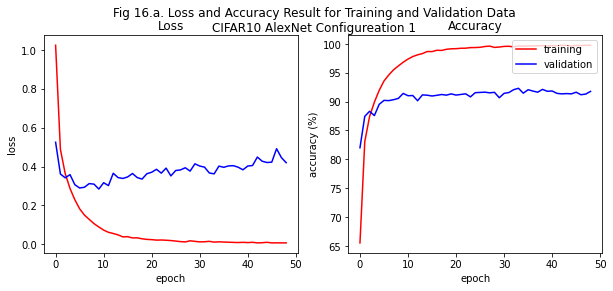



Fig 16.b Classification Report: CIFAR10 AlexNet Configureation 1"


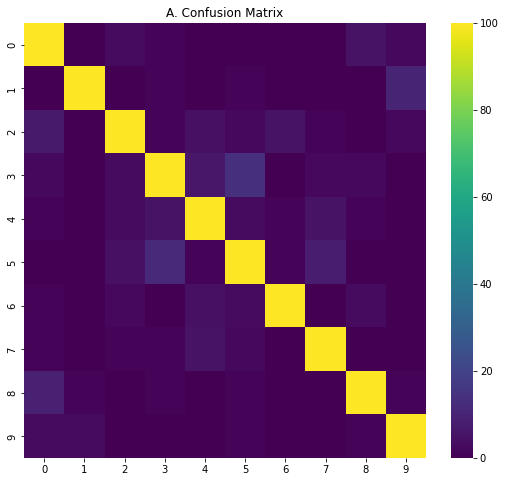

Accuracy: 98.4%


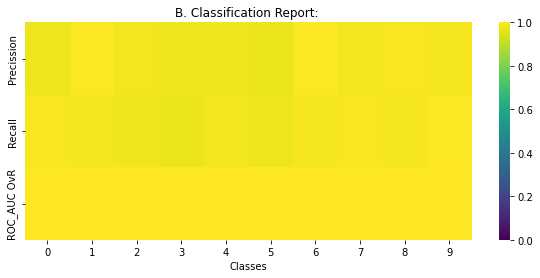

C. Top 5 class ROC-AUC OvR


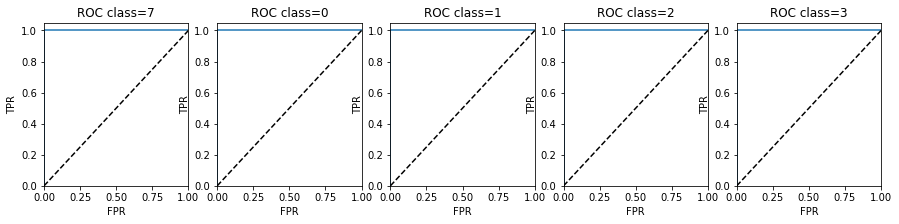

{'accuracy': 0.9838,
 'precision': 0.9836954670719139,
 'recalls': 0.9837098680217504}

In [ ]:
classes_CIFAR=np.arange(0,10)
net_alex=models.alexnet(weights='DEFAULT')
net_alex.classifier[6] = nn.Linear(4096,10)
result_path_alex=ROOT_WORK+'results/AlexNet_CIFAR.pt'
graph_result(result_path_alex,"Fig 16.a. Loss and Accuracy Result for Training and Validation Data\nCIFAR10 AlexNet Configureation 1")
print('\n==================================================\n')
confusion_mat(net_alex,result_path_alex,classes_CIFAR,valid_dl_c,'Fig 16.b Classification Report: CIFAR10 AlexNet Configureation 1"')

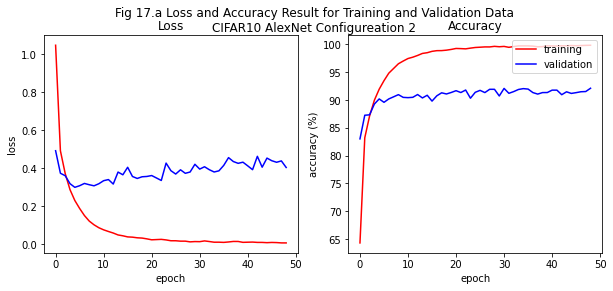



Fig 17.b Classification Report: CIFAR10 AlexNet Configureation 2"


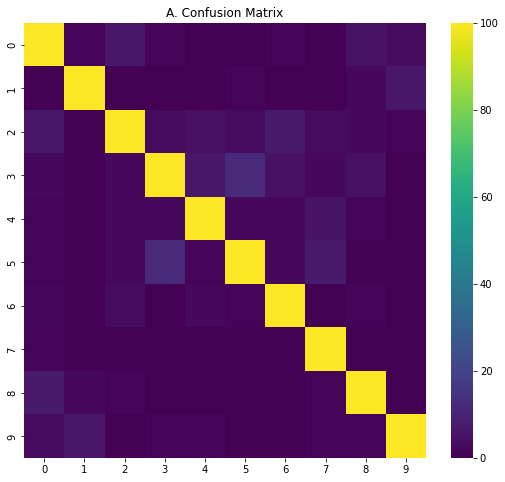

Accuracy: 98.4%


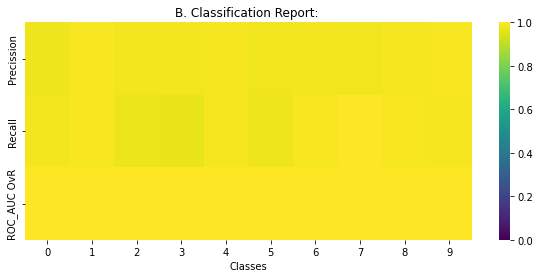

C. Top 5 class ROC-AUC OvR


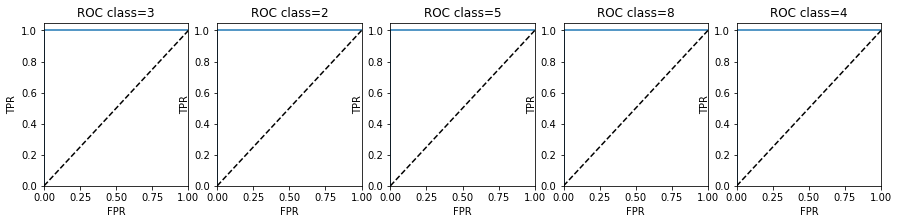

{'accuracy': 0.984,
 'precision': 0.9838905495043871,
 'recalls': 0.983938889254811}

In [ ]:
classes_CIFAR=np.arange(0,10)
net_alex_2=models.alexnet(weights='DEFAULT')
for i in net_alex_2.features:
  i.requires_grad=False
net_alex_2.classifier[6] = nn.Linear(4096,10)
result_path_alex=ROOT_WORK+'results/AlexNet_CIFAR_2.pt'
graph_result(result_path_alex,"Fig 17.a Loss and Accuracy Result for Training and Validation Data\nCIFAR10 AlexNet Configureation 2")
print('\n==================================================\n')
confusion_mat(net_alex_2,result_path_alex,classes_CIFAR,valid_dl_c,'Fig 17.b Classification Report: CIFAR10 AlexNet Configureation 2"')

In [ ]:
d_1 = torch.load(ROOT_WORK+'results/AlexNet_CIFAR.pt')
d_2 = torch.load(ROOT_WORK+'results/AlexNet_CIFAR_2.pt')

At a glance, both figure 16 and 17 are quite similar, for the loss and accuracy movement and accuracy. It shows that the Alex Net can handle CIFAR10 images data. However, the computation cost of first configuration is quite high, since the models need to re-trained again using the CIFAR10 dataset. On other hands, the models with second configurations does not need high computation cost, since the weight for base convolution blocks are froze (unchanged).

## 5 Model comparisons [14 marks]


INSTRUCTION:
We often need to compare our model with other state-of-the-art methods to understand how well it performs compared to existing architectures. Here you will thus compare your model design with AlexNet on the TinyImageNet30 dataset

#### 5.1 Finetune AlexNet on TinyImageNet30
> Load AlexNet as you did above

> Train AlexNet on TinyImageNet30 dataset until convergence. Make sure you use the same dataset

Here we load the Alex Net models and applying second configurations. Besides that, we also create dataaugmentation transformation specializing the application in tiny image net. This are performed to achieve similar augmentation conditions that used in best model.

In [ ]:
transform_aug_alex_tinyimageNet= transforms.Compose([
    transforms.Resize(224),
    transforms.RandomPerspective(distortion_scale=0.7, p=0.2), ## Random Prespective
    transforms.RandomResizedCrop(size=(224),scale=(0.5,1)), ## Crop and Resize the crop file
    transforms.RandomHorizontalFlip(p=0.5), ## Random Horizontal Flip
    transforms.RandomVerticalFlip(p=0.5),   ## Random Vertical Flip
    transforms.ColorJitter(brightness=.5, hue=.3), ## Random Color Jitter
    transforms.RandomAdjustSharpness(sharpness_factor=2), ## Random Adjust Sharpness
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

In [ ]:
dataset_aug_alex = ImageFolder(root=train_path,transform=transform_aug_alex_tinyimageNet)
# create the dataset
train_ds_aug_alex, valid_ds_aug_alex = torch.utils.data.random_split(dataset_aug_alex, [0.8, 0.2])
# create the dataloader
train_dl_aug_alex = DataLoader(train_ds_aug_alex,batch_size=64,shuffle=True, num_workers=2)
valid_dl_aug_alex = DataLoader(valid_ds_aug_alex,batch_size=64,shuffle=True, num_workers=2)

In [ ]:
# Your code here!
# Froze the base convolution block => FIRST CONV AND FIRST POOLING
net_alex_2=models.alexnet(weights='DEFAULT')

# Froze the base convolution block => FIRST CONV AND FIRST POOLING
for i in net_alex_2.features:
  i.requires_grad=False
# Reinitiate the last layer adapting 30 classes
net_alex_2.classifier[6] = nn.Linear(4096,30)

result_path_alex2=ROOT_WORK+'results/AlexNet_aug_data.pt'

training_netlayer(net_alex_2, 50, result_path_alex2, train_dl_aug_alex,valid_dl_aug_alex,0.001,device,0.9,True)

Resuming Training process- epoch: 10 training loss:  1.197 training accuracy:  63.409%  valid loss:  1.336 valid accuracy: 59.569%
Saving a checkpoint - epoch: 15 training loss:  1.035 training accuracy:  68.032%  valid loss:  1.262 valid accuracy: 62.270%
Saving a checkpoint - epoch: 20 training loss:  0.972 training accuracy:  70.168%  valid loss:  1.279 valid accuracy: 63.372%
Saving a checkpoint - epoch: 25 training loss:  0.912 training accuracy:  71.912%  valid loss:  1.249 valid accuracy: 63.009%
Saving a checkpoint - epoch: 30 training loss:  0.830 training accuracy:  73.786%  valid loss:  1.274 valid accuracy: 64.196%
Saving a checkpoint - epoch: 35 training loss:  0.772 training accuracy:  75.792%  valid loss:  1.258 valid accuracy: 63.614%
Saving a checkpoint - epoch: 40 training loss:  0.722 training accuracy:  77.225%  valid loss:  1.270 valid accuracy: 64.026%
Saving a checkpoint - epoch: 45 training loss:  0.671 training accuracy:  78.470%  valid loss:  1.313 valid accur

In [ ]:
transform_3_alex= transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])
dataset_alex = ImageFolder(root=train_path,transform=transform_3_alex)
# create the dataset
train_ds_alex, valid_ds_alex = torch.utils.data.random_split(dataset_alex, [0.8, 0.2])
# create the dataloader
train_dl_alex = DataLoader(train_ds_alex,batch_size=64,shuffle=True, num_workers=2)
valid_dl_alex = DataLoader(valid_ds_alex,batch_size=64,shuffle=True, num_workers=2)

#### 5.2 Compare results on validation set of TinyImageNet30
> Loss graph, top1 accuracy, confusion matrix and execution time for your model (say, mymodel and AlexNet)


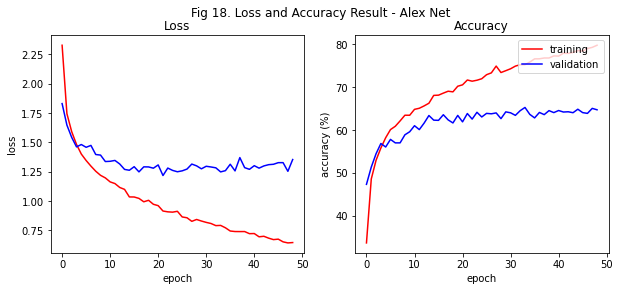



Fig 19. Classification Report: Alex Net


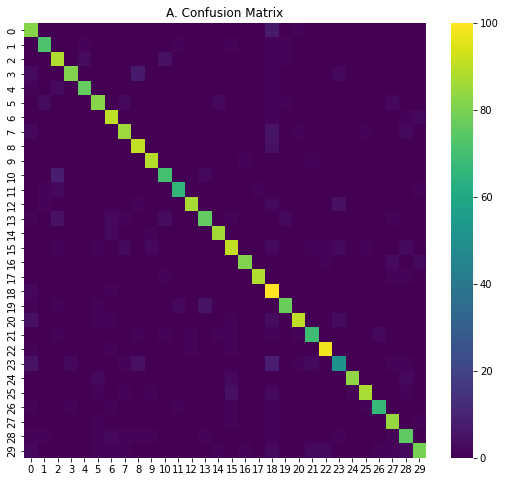

Accuracy: 90.4%


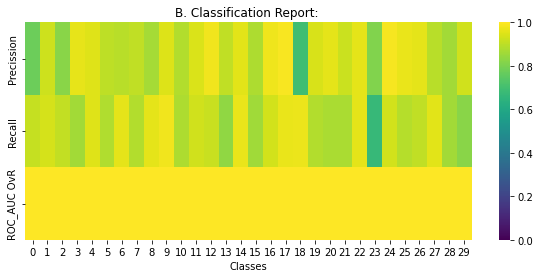

C. Top 5 class ROC-AUC OvR


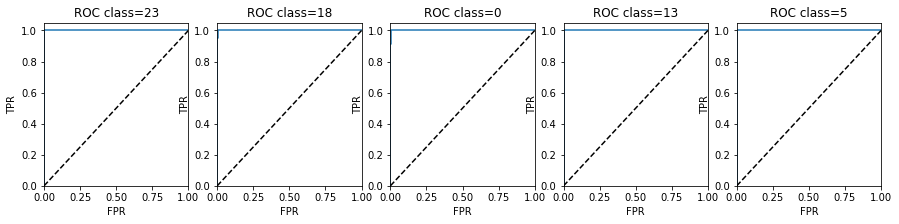

{'accuracy': 0.9044444444444445,
 'precision': 0.9108434971728626,
 'recalls': 0.9034835156325199}

In [ ]:
net_alex_2=models.alexnet(weights='DEFAULT')
for i in net_alex_2.features:
  i.requires_grad=False
net_alex_2.classifier[6] = nn.Linear(4096,30)
result_path_alex=ROOT_WORK+'results/AlexNet_aug_data.pt'
graph_result(result_path_alex,"Fig 18. Loss and Accuracy Result - Alex Net")
print('\n==================================================\n')
classes=np.arange(0,30)
confusion_mat(net_alex_2,result_path_alex,classes,valid_dl_alex,'Fig 19. Classification Report: Alex Net')

As shown in figure 18, Alex Net is faster to reach convergences compare my models. With only 10 epochs, it already get loss lower than 1.5. Besides that the accuracy are also higher. The accuracy of Alex Net is 90%, which 3% higher than my models. Since the epochs needed for training data is lower than my models, the execution times is only 1 hours, compared my models which takes three times. It can be achieved due to pretrained configuration and frozen layer. Since the AlexNet is already trained using huge ImageNet data, the weight of each layer are already adjusted.

## 6 Interpretation of results (16 marks)

> Please use TinyImageNet30 dataset for all results


## 6.1-6.2 Implement grad-CAM and visualise results (10 marks)

- Use an existing library to initiate grad-CAM

        - To install: !pip install torchcam
        - Call SmoothGradCAMpp: from torchcam.methods import SmoothGradCAMpp
        - Apply to your model

You can see the details here: https://github.com/frgfm/torch-cam

- Apply grad-CAM to your model on at least four correctly classified images
- Apply grad-CAM on retrained AlexNet on at least four incorrectly classified images

>It is recommended to first read the relevant paper [Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization](https://arxiv.org/abs/1610.02391), and refer to relevant course material.


**HINT for displaying images with grad-CAM:**

Display ```heatmap``` as a coloured heatmap superimposed onto the original image. We recommend the following steps to get a clear meaningful display.

From torchcam.utils import overlay_mask. But remember to resize your image, normalise it and put a 1 for the batch dimension (e.g, [1, 3, 224, 224])


In [ ]:
!pip install torchcam

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


This code for checking the correct or false predictions of the classifications.

In [ ]:
def getdifferent(net_1,state_1, data_loader,k, checking_state):
  d_1 = torch.load(state_1)
  net_1.load_state_dict(d_1["model_state_dict"])
  net_1.eval()

  dict_net_1super={}
  counter=0
  with torch.no_grad():
    for data in data_loader:
      images, labels = data
      images=images.cuda()
      outputs = net_1(images)
      _, predicted_1 = torch.max(outputs, 1)
      if checking_state==True:
        if (predicted_1.item()==labels):
          dict_output={}
          dict_output['images']=images.cpu()
          dict_output['true_label']=labels.cpu().item()
          dict_output['net_1pred']=predicted_1.cpu().item()
          dict_net_1super[counter]=dict_output
          counter+=1
      else:
        if (predicted_1.item()!=labels):
          dict_output={}
          dict_output['images']=images.cpu()
          dict_output['true_label']=labels.cpu().item()
          dict_output['net_1pred']=predicted_1.cpu().item()
          dict_net_1super[counter]=dict_output
          counter+=1
      if counter>k:
        break
  return dict_net_1super

In [ ]:
from torchcam.methods import SmoothGradCAMpp
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD = [0.229, 0.224, 0.225]

def denormalize(x, mean=IMG_MEAN, std=IMG_STD):
    # 3, H, W, B
    ten = x.clone().permute(1, 2, 3, 0)
    for t, m, s in zip(ten, mean, std):
        t.mul_(s).add_(m)
    # B, 3, H, W
    return torch.clamp(ten, 0, 1).permute(3, 0, 1, 2)

def picturing_comparison(dict_output,net_1,state_1, target_layer,model,checking_state,path_save):
  d_1 = torch.load(state_1)
  net_1.load_state_dict(d_1["model_state_dict"])
  net_1.eval()

  len_k=len(dict_output)
  fig, axs = plt.subplots(nrows=len_k,ncols=2,figsize=(len_k,2*len_k))
  temp_=None
  for i in np.arange(0,len_k):
    cam_extractor=SmoothGradCAMpp(net_1,target_layer=[target_layer])
    net_1.cpu()
    y_ = net_1(dict_output[0]['images'].cpu())
    _, index_ = torch.max(y_, 1)
    activation_map_1 = cam_extractor(index_.item(), y_)

    img_1=dict_output[i]['images']#[0]
    img_1 = np.transpose((denormalize(img_1)*255).numpy()[0].astype(np.uint8),(1,2,0))
    result_1 = overlay_mask(to_pil_image(img_1.astype(np.uint8)),
                          to_pil_image(activation_map_1[0].squeeze(0), mode='F'),
                          alpha=0.5)


    axs[i][0].imshow(to_pil_image(img_1.astype(np.uint8)))
    to_pil_image(img_1.astype(np.uint8)).save(path_save+'/'+model+'_'+checking_state+'_'+str(i).zfill(2)+'_true.jpg')
    axs[i][1].imshow(result_1)
    result_1.save(path_save+'/'+model+'_'+checking_state+'_'+str(i).zfill(2)+'.jpg')
    axs[i][0].set_title('True Labels: ' +str(dict_output[i]['true_label']))
    axs[i][1].set_title('Predictions Model: ' +str(dict_output[i]['net_1pred']))
    axs[i][0].axis('off')
    axs[i][1].axis('off')
    temp_=dict_output[i]['images']
  fig.suptitle('GradCam Visualization')
  plt.tight_layout()

  plt.show()

## 6.1 Implement grad-CAM for visualize the prediction from my models.

Here we will visualize the prediction results of my models.

In [ ]:
dataset = ImageFolder(root=train_path,transform=transform_1)
grad_dl = DataLoader(dataset,batch_size=1,shuffle=True, num_workers=2)


In [ ]:
net = NetCNNDropout(dropout_r=0.25)
net=net.to(device)
results_path=ROOT_WORK+'/results/CNNclassifier100epochs_25d.pt'

dict_output=getdifferent(net,results_path,grad_dl,5,True)

Figure 20.A Correct Classification of my models


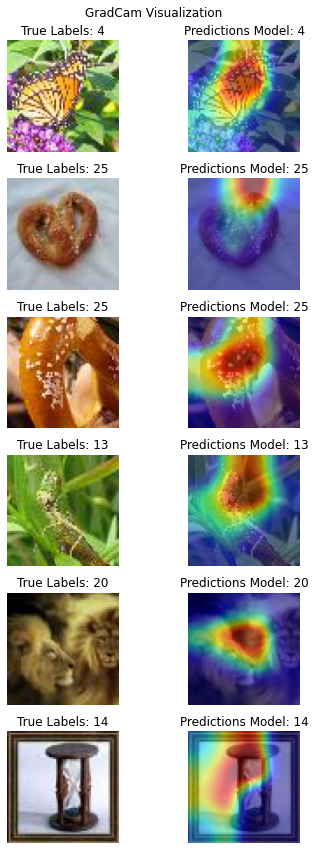

In [ ]:
print('Figure 20.a Correct Classification of my models')
picturing_comparison(dict_output,net,results_path,'conv2_10','mymodel','Correct',ROOT_WORK+'/results/')

Figure 20.b Incorrect Classification of my models


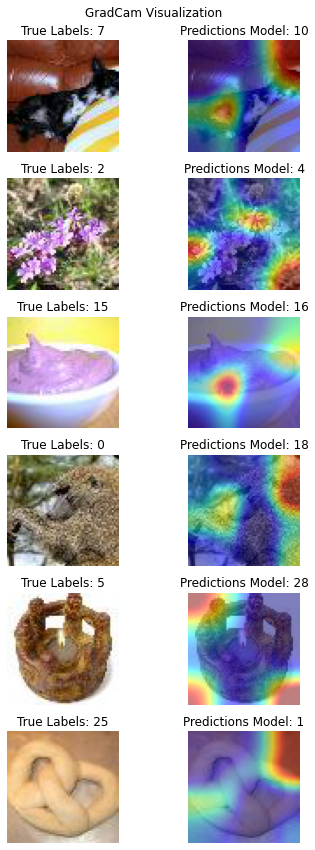

In [ ]:
net = NetCNNDropout(dropout_r=0.25)
net=net.to(device)
results_path=ROOT_WORK+'/results/CNNclassifier100epochs_25d.pt'
dict_output=getdifferent(net,results_path,grad_dl,5,False)
print('Figure 20.b Incorrect Classification of my models')
picturing_comparison(dict_output,net,results_path,'conv2_10','mymodel','Incorrect',ROOT_WORK+'/results/')

## 6.2 Implement grad-CAM for visualize the prediction from Alex Net

Here we will visualize the prediction results of my models.

In [ ]:
dataset = ImageFolder(root=train_path,transform=transform_3_alex)
grad_dl = DataLoader(dataset,batch_size=1,shuffle=True, num_workers=2)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


  0%|          | 0.00/233M [00:00<?, ?B/s]

Figure 21.a Correct Classification of ALEX NET


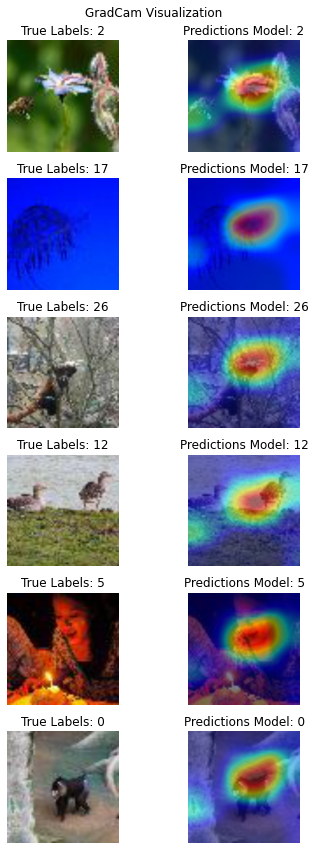

In [ ]:
net_alex_2=models.alexnet(weights='DEFAULT')
for i in net_alex_2.features:
  i.requires_grad=False
net_alex_2.classifier[6] = nn.Linear(4096,30)
net_alex_2.to(device)
result_path_alex=ROOT_WORK+'results/AlexNet_aug_data.pt'


dict_output=getdifferent(net_alex_2,result_path_alex,grad_dl,5,True)
print('Figure 21.a Correct Classification of ALEX NET')
picturing_comparison(dict_output,net_alex_2,result_path_alex,'avgpool','alexnet','Correct',ROOT_WORK+'/results/')

Figure 21.b Incorrect Classification of ALEX NET


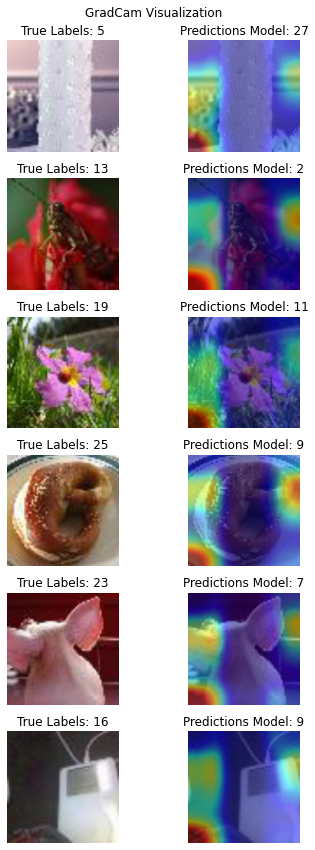

In [ ]:
net_alex_2=models.alexnet(weights='DEFAULT')
for i in net_alex_2.features:
  i.requires_grad=False
net_alex_2.classifier[6] = nn.Linear(4096,30)
net_alex_2.to(device)
result_path_alex=ROOT_WORK+'results/AlexNet_aug_data.pt'


dict_output=getdifferent(net_alex_2,result_path_alex,grad_dl,5,False)
print('Figure 21.b Incorrect Classification of ALEX NET')
picturing_comparison(dict_output,net_alex_2,result_path_alex,'avgpool','alexnet','Incorrect',ROOT_WORK+'/results/')

#### 6.3 Your comments on (6 marks):
> a) Why model predictions were correct or incorrect?

- From the figure 20, my best model can predict well on object-centered with at least medium size object and contrast color. However, my model is likely fails detecting small object with similar color with backgrounds. Besides that, when the image is small and there is another big object surronded it.

- Similarly, AlexNet also shows similar behaviour based on figure 21. Additionally, AlexNet is also fails recognize the full covered from cropped images.


> b) What can you do to improve your results further?

- Based on the comparisons, several improvement can be made:
1. Make augmentation of crop and strecth or strecthing the images after random prespective
2. Apply albuminations, such as implemented in https://github.com/albumentations-team/albumentations
3. Checking different kernel size and paddings. Since I choose 3x3 kernel size, perhaps 5x5 can improve the progress
4. Using the adaptive pool for simplifying the input configuration of fully connected layers
5. Combined results of alexnet and mymodels, by ensembling the loss
6. Using scheduler to change the learning rate after appropriate epochs (like after 100th change from 0.001 to 0.0001).

**Please refer to the submission section at the top of this notebook to prepare your submission. Use our teams channel to seek any help!**
